<a href="https://colab.research.google.com/github/Saltizm/Data-mining-group-project/blob/main/code_copy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sklearn as sk;
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OrdinalEncoder, KBinsDiscretizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd;
import numpy as np;
import seaborn as sns;
import matplotlib.pyplot as plt;
import tqdm;
import os;
import sys;

In [2]:
# # # mount
# from google.colab import drive
# drive.mount('/content/drive')

In [3]:
if os.path.isdir(r'C:\Users\User\Desktop\Data-mining-group-project'):
    os.chdir(r'C:\Users\User\Desktop\Data-mining-group-project') #local
elif os.path.isdir(r'/content/drive/MyDrive/data mining'):
    os.chdir(r'/content/drive/MyDrive/data mining') #google drive
try:
    train = pd.read_csv(open('UNSW_NB15_training-set.csv', encoding='utf-8'))
    test = pd.read_csv(open('UNSW_NB15_testing-set.csv', encoding='utf-8'))
except FileNotFoundError as e:
    print(f"error: {e}\nTry changing the training data directory in 'os.chdir'")

In [4]:
# Set parameters
OUTLIER_THRESHOLD = 0.1
FEATURE_THRESHOLD = 0.1
BIN_THRESHOLD = 0.1

In [5]:
np.random.seed(42)

In [6]:
# if data too big (use for testing)
# train = train.sample(frac=0.1)
# test = test.sample(frac=0.1)

In [7]:
print(train.shape, test.shape)
# 45 attributes

(175341, 45) (82332, 45)


In [8]:
train.isnull().any(axis=1).sum()

0

In [9]:
test.isnull().any(axis=1).sum()

0

In [10]:
# import files
train = train.sample(frac=1)
test = test.sample(frac=1)
x_train, y_train = train.iloc[:, :-2], train.iloc[:, -2:]
x_test, y_test = test.iloc[:, :-2], test.iloc[:, -2:]

In [11]:
y_train.columns

Index(['attack_cat', 'label'], dtype='object')

In [12]:
def show_outliers_iqr(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (lower_bound, upper_bound)

# data cleaning (replacement)
def replace_outliers_iqr(df, cols):
    for col in cols:
        if col in df.columns:
            lower_bound, upper_bound = show_outliers_iqr(df[col])
            df[col] = df[col].clip(lower=lower_bound, upper=upper_bound)
    return df

# data filtering
def remove_outliers_iqr(df, cols):
    overall_mask = pd.Series(True, index=df.index)

    for col in cols:
        if col in df.columns:
            lower_bound, upper_bound = show_outliers_iqr(df[col])
            col_mask = (df[col] >= lower_bound) & (df[col] <= upper_bound)
            overall_mask = overall_mask & col_mask

    df = df[overall_mask]
    return df

def risky_show_shape(*arg):
    if len(arg) == 2:
        print("train/test")
        print(arg[0].shape, arg[1].shape)
    else:
        print("x_train/x_test/y_train/y_test")
        for df in arg:
            print(df.shape)

def run_model(model, x_train, y_train, x_test, y_test):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    return y_pred

def plot_histograms(df, numerical_cols, frac=0.1, title='graph'):
    df = df.copy().sample(frac=frac)
    # Filter numerical_cols to only include those present in binned_x_train
    columns_to_plot = [col for col in numerical_cols if col in df.columns]

    # Calculate grid dimensions
    num_plots = len(columns_to_plot)
    num_cols = 4
    num_rows = (num_plots + num_cols - 1) // num_cols # Equivalent to ceil(num_plots / num_cols)

    plt.figure(figsize=(20, num_rows * 5)) # Adjust figure size for better readability

    for i, col in enumerate(columns_to_plot):
        ax = plt.subplot(num_rows, num_cols, i + 1) # Create subplot
        sns.histplot(df[col], kde=True, ax=ax)
        ax.set_title(f'Histogram of {col}')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')

    # Hide any unused subplots if the last row is not full
    for j in range(i + 1, num_rows * num_cols):
        plt.subplot(num_rows, num_cols, j + 1).set_visible(False)

    plt.title(title)
    plt.tight_layout()
    plt.show()

# def bin_decision(unique_series, threshold=0.2):
#     keep = []

#     val_count = unique_series.value_counts()
#     for col in val_count.index:
#         if val_count[col] / unique_series.shape[0] > threshold:
#             keep.append(col)
#     return keep

# def binning(df, col, values):
#     df = df.copy()

#     for val in values:
#         df[col].replace(val, 'Others', inplace=True)
#     return df

class Plot(BaseEstimator, TransformerMixin):
    def __init__(self, frac=0.1, title='graph'):
        self.frac = frac
        self.title = title

    def fit(self, X, y=None):
        print(X.shape)
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            # Create a DataFrame from the numpy array for plotting purposes
            temp_df = pd.DataFrame(X)
            cols_to_plot = list(range(X.shape[1]))
        elif isinstance(X, pd.DataFrame):
            temp_df = X
            cols_to_plot = X.columns.tolist()
        else:
            raise TypeError("Input must be a pandas DataFrame or a numpy array.")

        plot_histograms(temp_df, cols_to_plot, self.frac, self.title)
        return X

class Add_feature(BaseEstimator, TransformerMixin):
    def __init__(self, feature_1, feature_2):
        self.feature_1 = feature_1
        self.feature_2 = feature_2

    def fit(self, X, y=None):
        print(X.shape)
        return self

    def transform(self, X):
        X = X.copy()
        X['new_feature'] = X[self.feature_1] + X[self.feature_2]
        return X

class Ratio_feature(BaseEstimator, TransformerMixin):
    def __init__(self, feature_1, feature_2):
        self.feature_1 = feature_1
        self.feature_2 = feature_2
        if self.feature_2 == 0:
            self.feature_2 = 1

    def fit(self, X, y=None):
        print(X.shape)
        return self

    def transform(self, X):
        X = X.copy()
        X['new_feature'] = X[self.feature_1] / X[self.feature_2]
        return X

class capping(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y=None):
        print(X.shape)
        return self

    def transform(self, X):
        output = replace_outliers_iqr(X, self.cols)
        return output

class filtering(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols

    def fit(self, X, y):
        return self

    def transform(self, X):
        output = remove_outliers_iqr(X, self.cols)
        return output

class Threshold_binning(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.2, other_label="Others"):
        self.threshold = threshold
        self.other_label = other_label

    def fit(self, X, y=None):
        print(X.shape)
        X = pd.DataFrame(X).copy()
        self.keep_ = {}

        for col in X.columns:
            freq = X[col].value_counts(normalize=True)
            self.keep_[col] = freq[freq > self.threshold].index

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        for col in X.columns:
            keep = self.keep_.get(col, [])
            X[col] = X[col].where(X[col].isin(keep), self.other_label)
        return X

class Pearson_feature_selection(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def fit(self, X, y):
        # Convert to DataFrame for correlation calculation
        X_df = pd.DataFrame(X) if not isinstance(X, pd.DataFrame) else X
        y_series = pd.Series(y) if not isinstance(y, pd.Series) else y

        # Calculate correlation between each feature and target
        correlations = X_df.corrwith(y_series).abs()

        # Keep features with correlation above threshold
        self.keep_ = correlations > self.threshold
        self.n_features_in_ = X_df.shape[1]
        self.n_features_out_ = self.keep_.sum()

        print(f'Pearson selection: {self.n_features_in_} -> {self.n_features_out_} features')

        return self

    def transform(self, X):
        # Always work with the boolean mask on columns
        if isinstance(X, pd.DataFrame):
            return X.loc[:, self.keep_]
        else:
            return X[:, self.keep_.values]
class Pearson_feature_selection(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.5):
        self.threshold = threshold

    def fit(self, X, y):
        # Convert to DataFrame/Series and align indices
        X_df = pd.DataFrame(X).reset_index(drop=True) if not isinstance(X, pd.DataFrame) else X.reset_index(drop=True)
        y_series = pd.Series(y).reset_index(drop=True) if not isinstance(y, pd.Series) else y.reset_index(drop=True)

        # Calculate absolute correlation with target
        correlations = X_df.corrwith(y_series).abs().fillna(0)

        # Select features above threshold
        self.keep_ = correlations > self.threshold
        self.n_features_in_ = X_df.shape[1]
        self.n_features_out_ = self.keep_.sum()

        print(f'Pearson selection: {self.n_features_in_} -> {self.n_features_out_} features (threshold={self.threshold})')

        return self

    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X.loc[:, self.keep_]
        else:
            return X[:, self.keep_.values]

class SafeLogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, replacement_value=1e-10):
        self.replacement_value = replacement_value

    def fit(self, X, y=None):
        print(X.shape)
        return self

    def transform(self, X):
        X_transformed = X.copy()

        # Replace zeros
        if hasattr(X, 'iloc'):  # DataFrame
            X_transformed = X.replace(0, self.replacement_value)
            # Apply log1p
            return np.log1p(X_transformed)
        else:  # NumPy array
            X_transformed[X == 0] = self.replacement_value
            return np.log1p(X_transformed)


message = """
plot_histograms(frac=0.1) -
plot a sampled subset of the data.

show_outliers_iqr(series) -
return an array where index=0 is the lower bound and index=1 is the upper bound.

replace_outliers_iqr(df, cols) -
creates a copy of "df". replace the samples with attributes > upper_bound or < lower_bound with upper_bound or lower_bound.

remove_outliers_iqr(df, cols) -
creates a copy of "df". remove the samples with attributes > upper_bound or < lower_bound.

risky_show_shape(*data) -
in the format of train/test. Or x_train, x_test, y_train, y_test.

run_model(model, x_train, y_train, x_test, y_test) -
runs the model and returns the prediction.

bin_decision(unique_series, threshold=0.2) -
receives a series df['col'].
get a list of value that represent less than x% of the total.

binning(df, col, values) -
replace a list of values with 'others' for one hot encoding later on.

---------------------------------------------------------------------------------------------------------------------------

User defined Transformer;

Plot(BaseEstimator, TransformerMixin) -
wrapper function for plot_histograms

Add_feature(BaseEstimator, TransformerMixin) -
Transformer that adds two numerical features to create a new secondary feature.

Ratio_feature(BaseEstimator, TransformerMixin) -
Transformer that divide two numerical features to create a new secondary feature.
if denominator value=0. reassign it to 1.

Capping/Filtering(BaseEstimator, TransformerMixin) -
wrapper function for replace_outliers_iqr/remove_outliers_iqr

Threshold_binning(BaseEstimator, TransformerMixin) -
bins values below a threshold into 'others'. Replacement for defunct binning and bin decision function rip

Pearson_feature_selection(BaseEstimator, TransformerMixin) -
select features based on corr coe

Safe_log_transform(BaseEstimator, TransformerMixin) -
replace zeros with a small number. Then apply log1p.
"""
print(message)


plot_histograms(frac=0.1) -
plot a sampled subset of the data.

show_outliers_iqr(series) -
return an array where index=0 is the lower bound and index=1 is the upper bound.

replace_outliers_iqr(df, cols) -
creates a copy of "df". replace the samples with attributes > upper_bound or < lower_bound with upper_bound or lower_bound.

remove_outliers_iqr(df, cols) -
creates a copy of "df". remove the samples with attributes > upper_bound or < lower_bound.

risky_show_shape(*data) -
in the format of train/test. Or x_train, x_test, y_train, y_test.

run_model(model, x_train, y_train, x_test, y_test) -
runs the model and returns the prediction.

bin_decision(unique_series, threshold=0.2) -
receives a series df['col'].
get a list of value that represent less than x% of the total.

binning(df, col, values) -
replace a list of values with 'others' for one hot encoding later on.

----------------------------------------------------------------------------------------------------------------------

In [13]:
# find numerical and non numerical fields
numerical_cols = x_train.select_dtypes(include=np.number).columns
non_numerical_cols = x_train.select_dtypes(exclude=np.number).columns

In [14]:
# find continuous and uniary fields (low and high cardinality)

low_cardinality_cols = []
high_cardinality_cols = []
continuous_cols = []

# Define a threshold for low cardinality. For example, less than 20 unique values.
CARDINALITY_THRESHOLD = 50

for col in numerical_cols:
    if col in ['id', 'label']:
        continue

    unique_count = x_train[col].nunique()
    if unique_count <= CARDINALITY_THRESHOLD:
        low_cardinality_cols.append(col)
    else:
        continuous_cols.append(col)

# Non-numerical columns can also be high cardinality if they have many unique categorical values
# This step categorizes based on numerical data first.
# Let's consider non-numerical columns for high cardinality if they have many unique values
for col in non_numerical_cols:
    if col in ['id', 'label']:
        continue
    unique_count = x_train[col].nunique()
    if unique_count > CARDINALITY_THRESHOLD:
        high_cardinality_cols.append(col)
    else:
        low_cardinality_cols.append(col)

In [15]:
print(f"Continuous Columns ({len(continuous_cols)}): {continuous_cols}")
print(f"Low Cardinality Columns ({len(low_cardinality_cols)}): {low_cardinality_cols}")
print(f"High Cardinality (Non-numerical) Columns ({len(high_cardinality_cols)}): {high_cardinality_cols}")

Continuous Columns (25): ['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload', 'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'stcpb', 'dtcpb', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'response_body_len', 'ct_srv_src', 'ct_dst_src_ltm', 'ct_srv_dst']
Low Cardinality Columns (16): ['sttl', 'dttl', 'swin', 'dwin', 'trans_depth', 'ct_state_ttl', 'ct_dst_ltm', 'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm', 'is_sm_ips_ports', 'service', 'state']
High Cardinality (Non-numerical) Columns (1): ['proto']


### Histograms for Continuous Columns

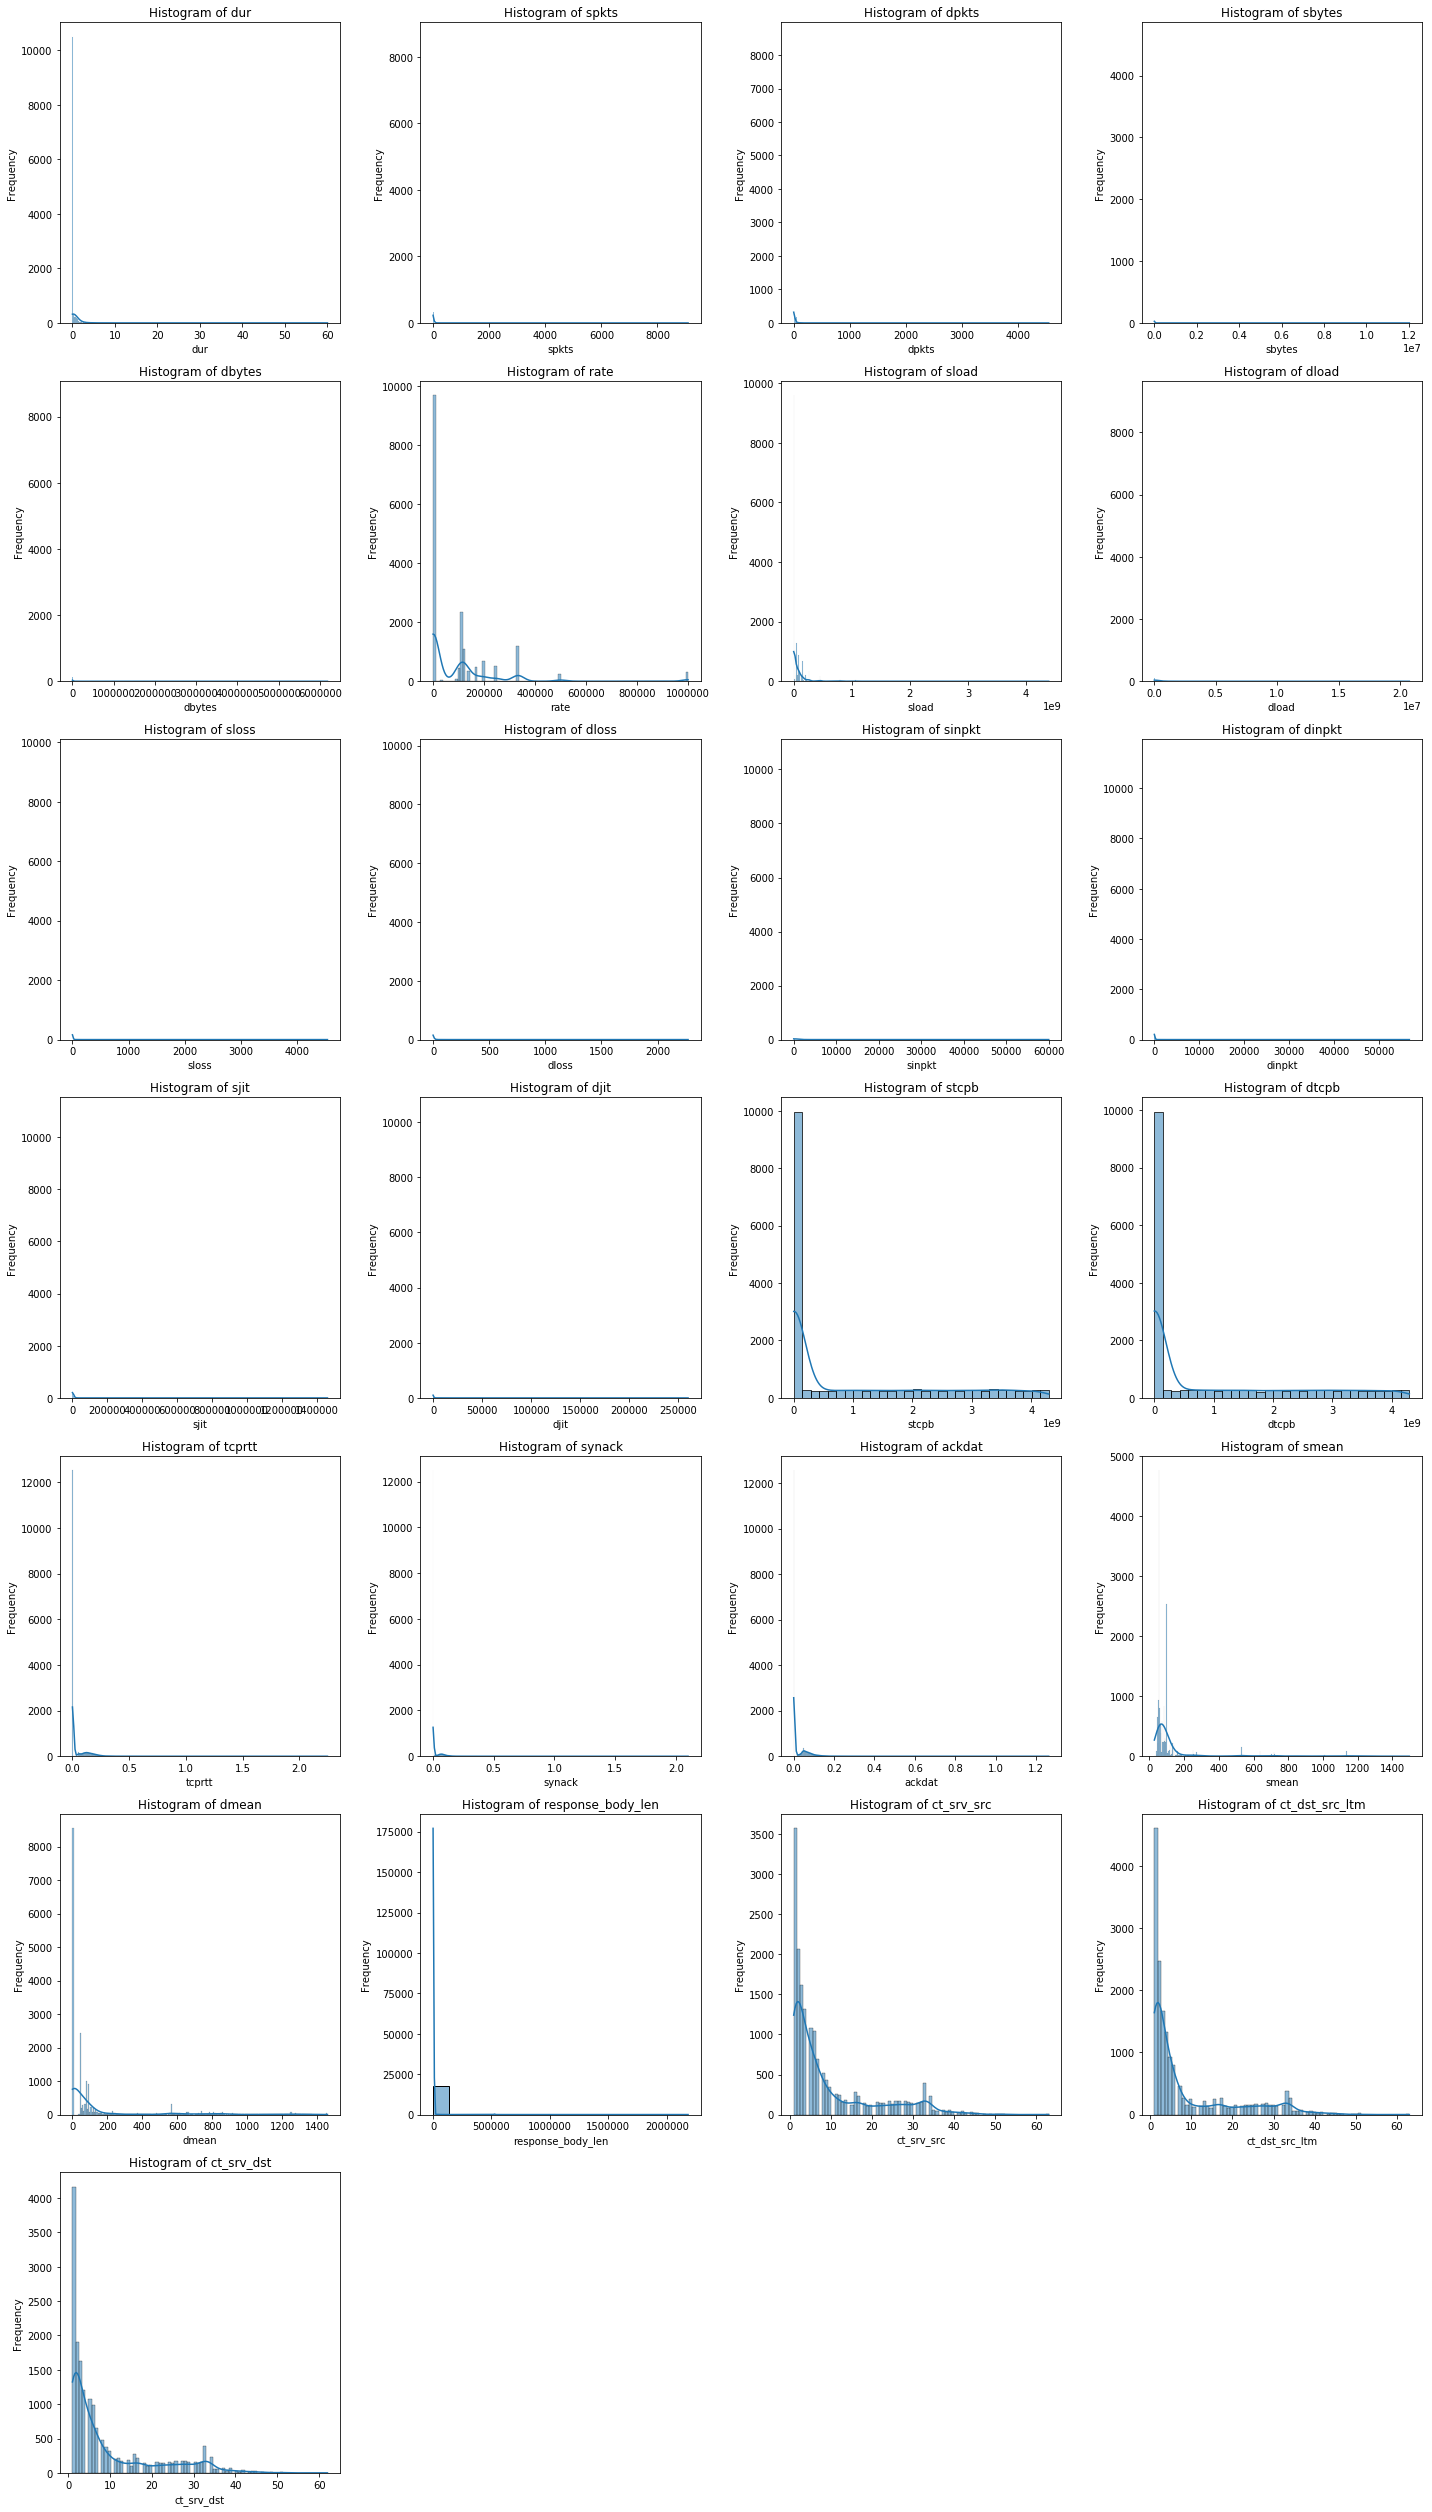

In [16]:
plot_histograms(x_train, continuous_cols)

### Histograms for Low Cardinality Columns

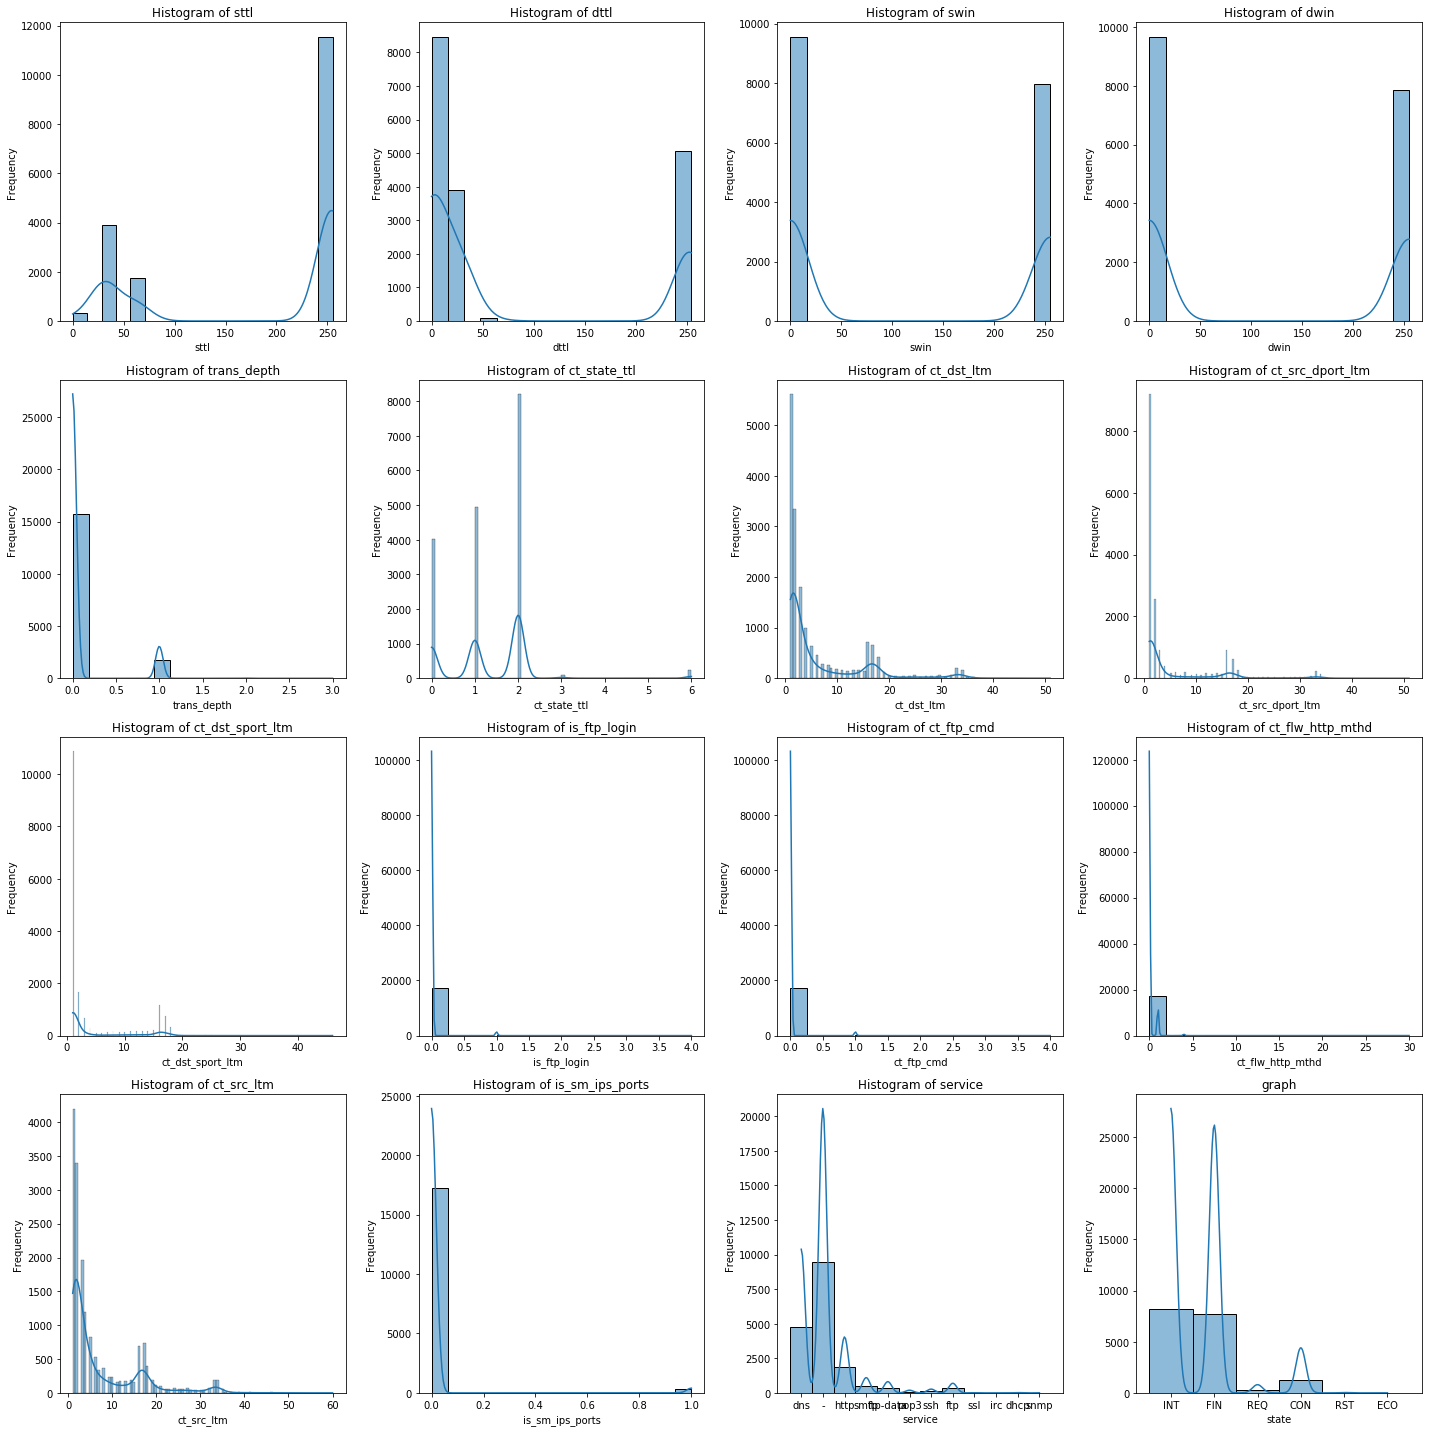

In [17]:
plot_histograms(x_train, low_cardinality_cols)

### Histograms for High Cardinality Columns

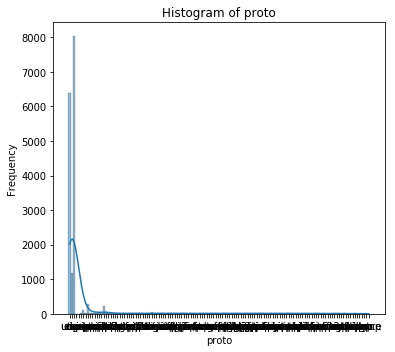

In [18]:
plot_histograms(x_train, high_cardinality_cols)

In [19]:
# checking if there are any outliers
outlier_data = []

for col in continuous_cols:
    lower_bound, upper_bound = show_outliers_iqr(train[col])
    lower_outliers_count = (x_train[col] < lower_bound).sum()
    upper_outliers_count = (x_train[col] > upper_bound).sum()
    non_outliers_count = len(x_train[col]) - (lower_outliers_count + upper_outliers_count)

    outlier_data.append({
        'Column': col,
        'Lower Bound Outlier %': f"{lower_outliers_count/len(x_train[col]):.2f}",
        'Upper Bound Outlier %': f"{upper_outliers_count/len(x_train[col]):.2f}",
        'Non-Outlier %': f"{non_outliers_count/len(x_train[col]):.2f}"
    })

# significant outliers
outlier_df = pd.DataFrame(outlier_data)
outlier_df_high = outlier_df[outlier_df['Upper Bound Outlier %'] > f'{OUTLIER_THRESHOLD}']
outlier_df_low = outlier_df[outlier_df['Upper Bound Outlier %'] < f'{OUTLIER_THRESHOLD}']
non_outlier_df = outlier_df[outlier_df['Upper Bound Outlier %'] == '0.00']
# outlier_df

In [20]:
outlier_df

,Column,Lower Bound Outlier %,Non-Outlier %,Upper Bound Outlier %
0,dur,0.00,0.91,0.09
1,spkts,0.00,0.86,0.14
2,dpkts,0.00,0.88,0.12
3,sbytes,0.00,0.87,0.13
4,dbytes,0.00,0.84,0.16
5,rate,0.00,0.90,0.10
6,sload,0.00,0.92,0.08
7,dload,0.00,0.78,0.22
8,sloss,0.00,0.93,0.07
9,dloss,0.00,0.84,0.16


In [21]:
print('non_outliers/ outlier_high /outlier_low')
print(non_outlier_df.shape, outlier_df_high.shape, outlier_df_low.shape)

non_outliers/ outlier_high /outlier_low
(2, 4) (15, 4) (10, 4)


Feature with highest absolute correlation to 'label': 
sttl                0.692741
ct_state_ttl        0.577704
dload               0.393739
ct_dst_sport_ltm    0.357213
dmean               0.341806
Name: label, dtype: float64
Highest correlation coefficient: 0.6927


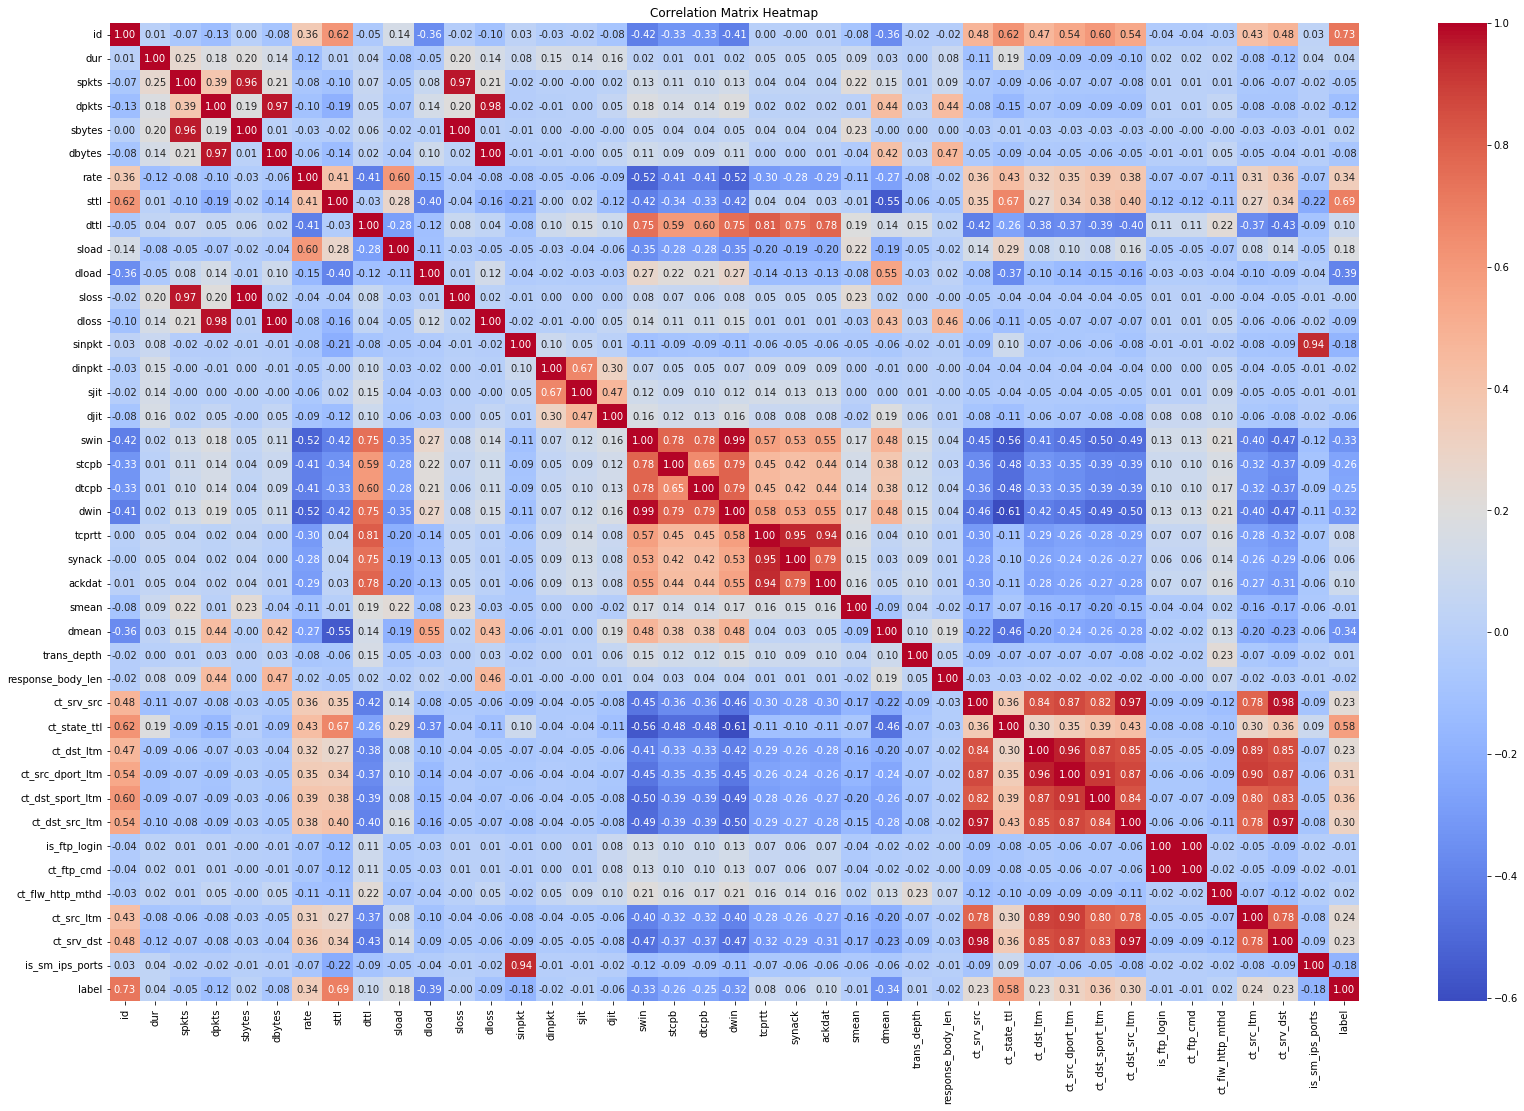

In [22]:
# Select only numerical columns before calculating correlation
corr_matrix = train.select_dtypes(include=[np.number]).corr()

# Get correlations with the 'label' column
label_correlations = corr_matrix['label'].drop('label').drop('id') # Exclude self-correlation

# Find the feature with the highest absolute correlation
top5_features = label_correlations.abs().nlargest(5)
highest_corr_value = top5_features.max()
print(f"Feature with highest absolute correlation to 'label': \n{top5_features}")
print(f"Highest correlation coefficient: {highest_corr_value:.4f}")

# 3. Plot the heatmap
plt.figure(figsize=(28, 18)) # Adjust figure size if needed
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

(175341, 41)
(175341, 42)
(175341, 43)
(175341, 44)
(175341, 45)
(175341, 46)
(175341, 47)
(175341, 48)
(175341, 49)
(175341, 50)
(175341, 51)
(175341, 52)
(175341, 53)
(175341, 54)
(175341, 55)
(175341, 56)
(175341, 57)
(175341, 58)
(175341, 59)
(175341, 60)
Feature with highest absolute correlation to 'label': 
sttl_ct_dst_sport_ltm_add            0.697012
sttl_ct_state_ttl_add                0.693757
dload_dmean_ratio                    0.483632
sttl_dmean_ratio                     0.458660
ct_state_ttl_ct_dst_sport_ltm_add    0.420729
Name: label, dtype: float64
Highest correlation coefficient: 0.6970


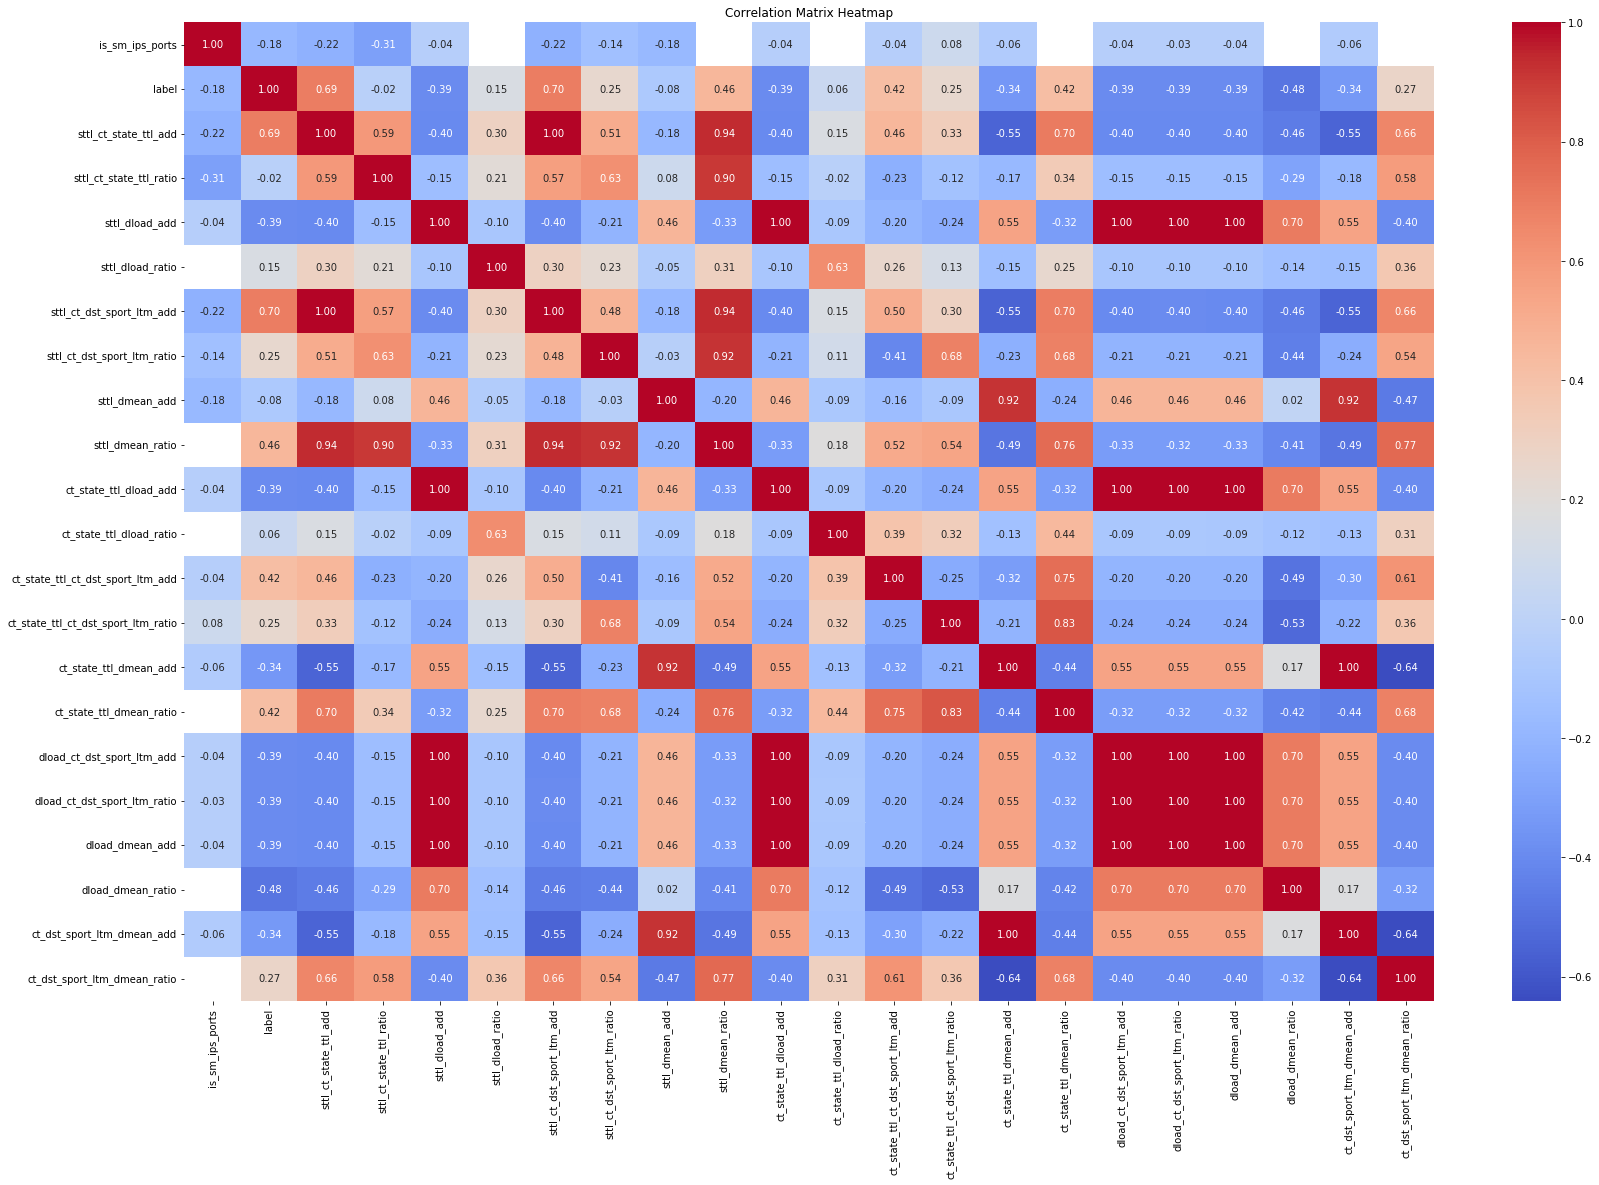

In [23]:
from itertools import combinations

pairs = combinations(top5_features.index, 2)

# Initialize temp with numerical columns from train. Correcting the TypeError here.
temp = train.select_dtypes(include=[np.number]).copy() # Use .copy() to avoid SettingWithCopyWarning later if modifying

for pair in pairs:
    feature1, feature2 = pair

    add_trans = Add_feature(feature1, feature2)
    ratio_trans = Ratio_feature(feature1, feature2)

    # Apply Add_feature and rename the new column to be unique
    transformed_add = add_trans.fit_transform(temp.copy()) # Use a copy to prevent in-place modification within transformer's fit_transform
    add_feature_name = f'{feature1}_{feature2}_add'
    temp[add_feature_name] = transformed_add['new_feature']

    # Apply Ratio_feature and rename the new column to be unique
    transformed_ratio = ratio_trans.fit_transform(temp.copy()) # Use a copy
    ratio_feature_name = f'{feature1}_{feature2}_ratio'
    temp[ratio_feature_name] = transformed_ratio['new_feature']

# After generating all new features, drop the original top5_features columns
# Correcting the inplace=True issue: assign the result back to temp.
# Use list() for columns and errors='ignore' to handle cases where top5_features.index might contain columns not in temp.
temp = temp.drop(columns=numerical_cols[:-1], errors='ignore')

# plot a coefficient matrix for temp
temp_corr_matrix = temp.corr()

# 3. Plot the heatmap
label_correlations = temp_corr_matrix['label'].drop('label') # Exclude self-correlation
top5_features = label_correlations.abs().nlargest(5)
highest_corr_value = top5_features.max()
print(f"Feature with highest absolute correlation to 'label': \n{top5_features}")
print(f"Highest correlation coefficient: {highest_corr_value:.4f}")

plt.figure(figsize=(28, 18)) # Adjust figure size if needed
sns.heatmap(temp_corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix Heatmap')
plt.show()

(175341, 40)
(175341, 40)
(175341, 39)
(175341, 39)


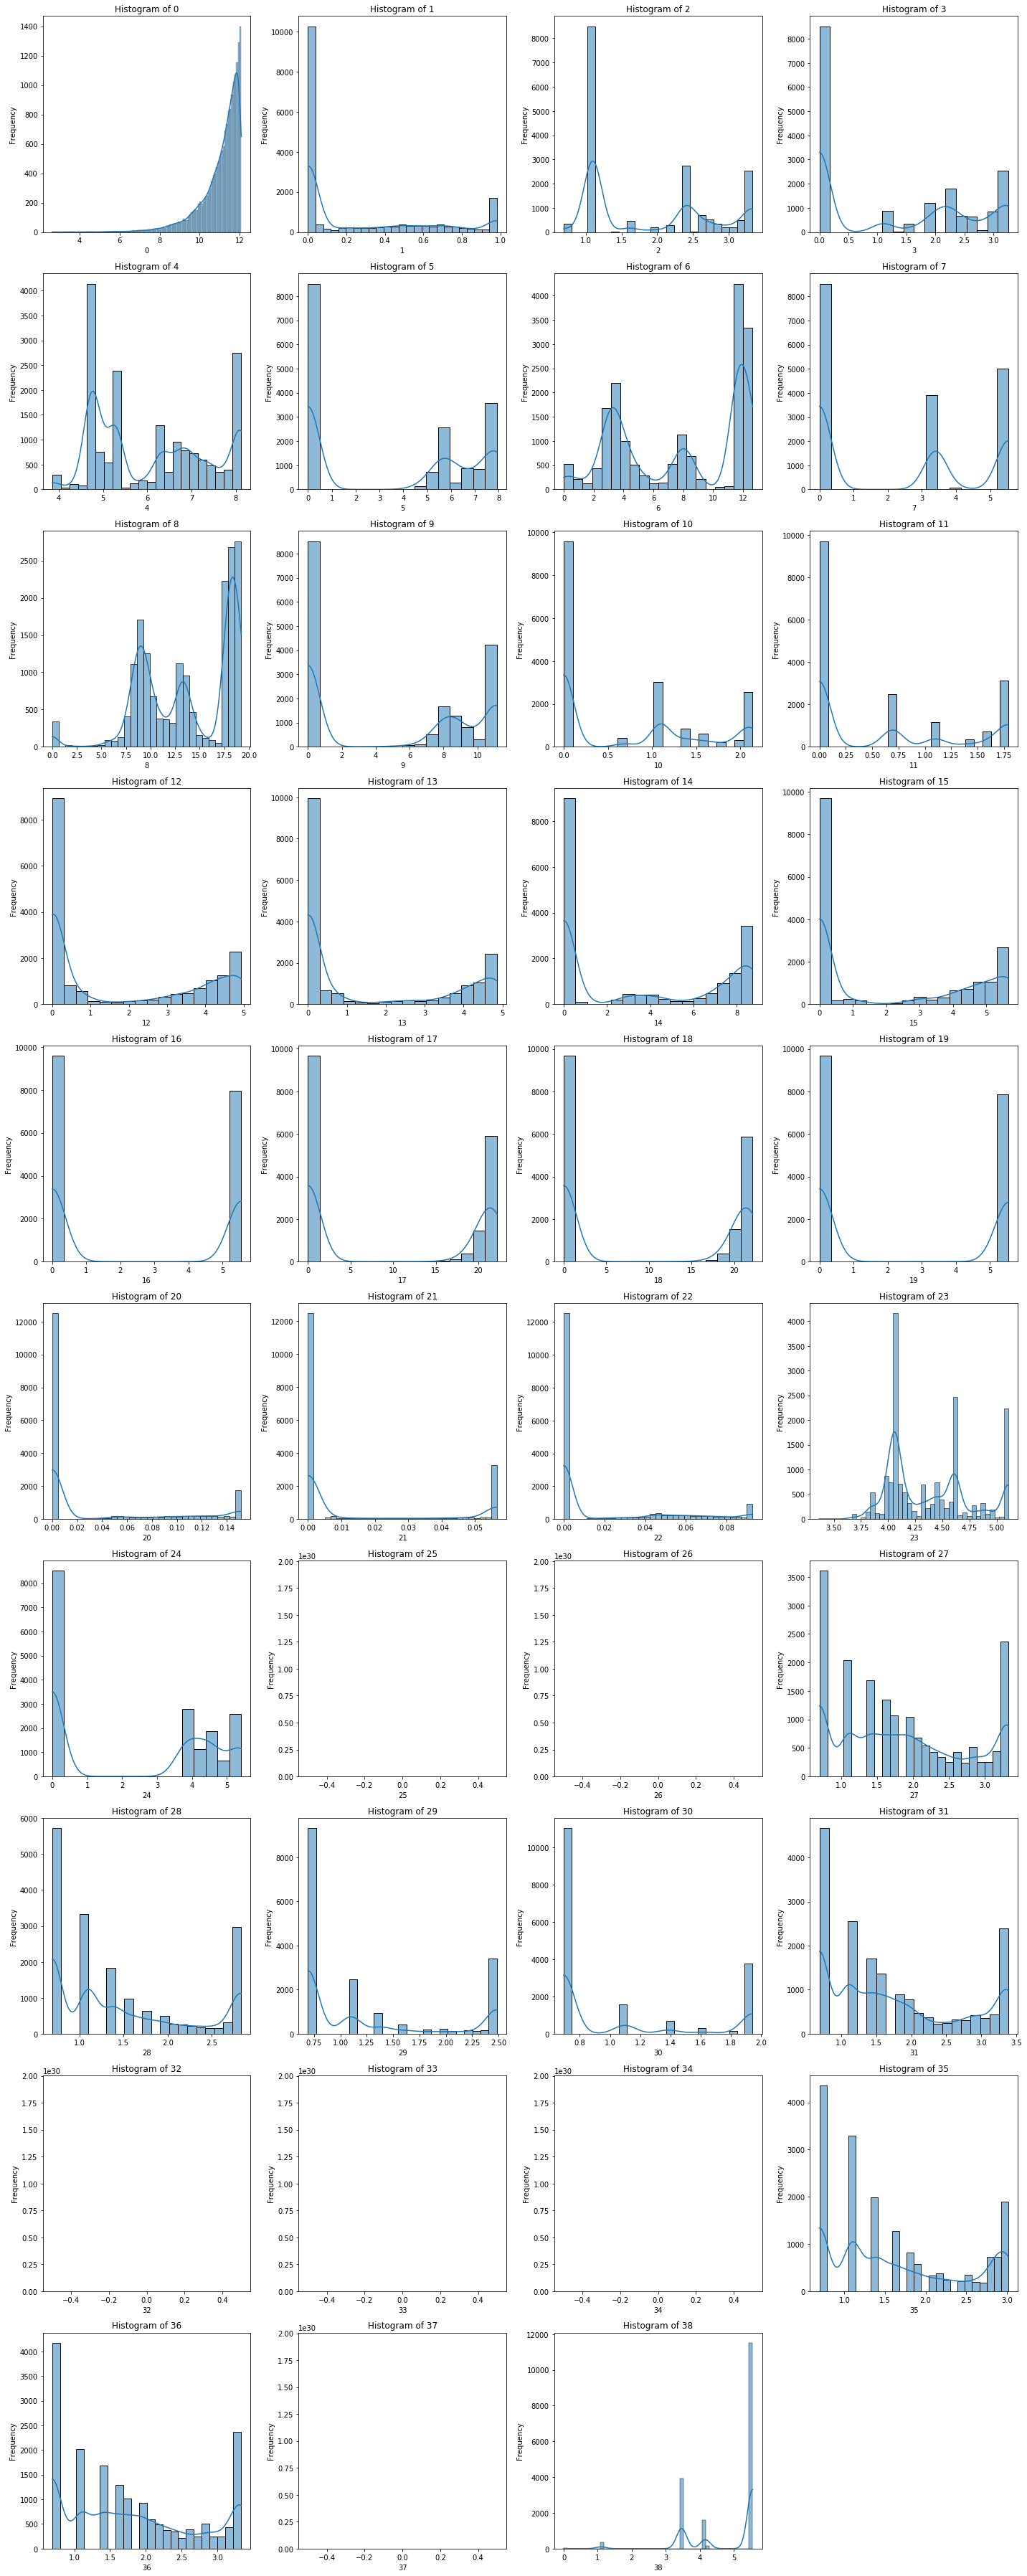

(175341, 3)
Pearson selection: 49 -> 37 features (threshold=0.1)


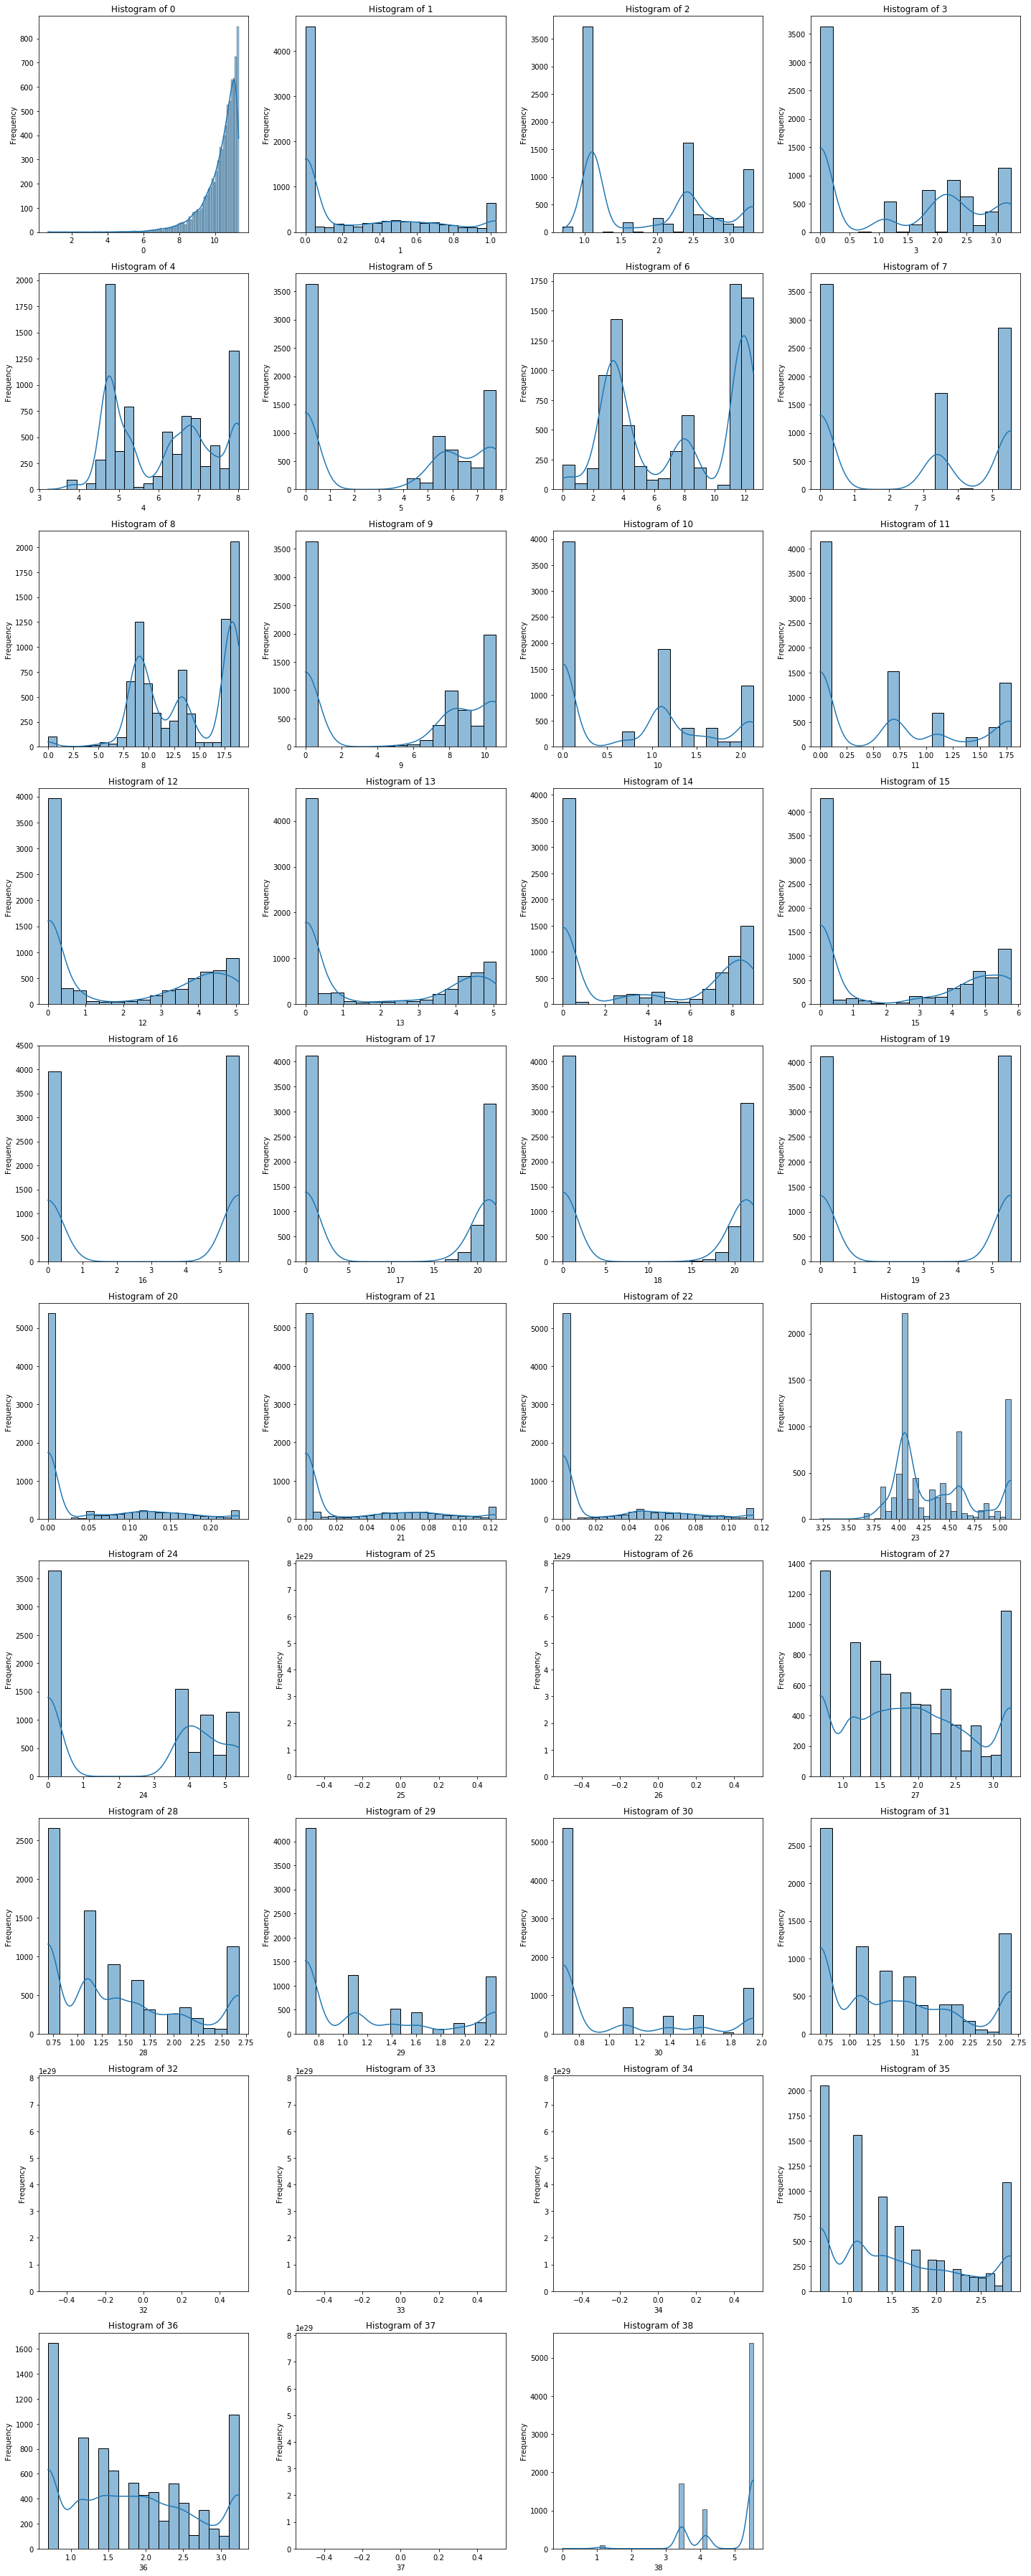

In [24]:
from sklearn.preprocessing import OneHotEncoder

column_modifier_core = Pipeline([
    ("ttl_sum", Add_feature('sttl', 'ct_state_ttl')),
    ("drop_original", ColumnTransformer(
        transformers=[
            ("drop_columns", "drop", ["sttl", "ct_state_ttl"])
        ], remainder="passthrough"
    ))
])

# Define the numerical pipeline
numerical_pipeline = Pipeline([
    ("capping", capping(numerical_cols)),
    # ("filtering", filtering(numerical_cols)),
    ("column_mod", column_modifier_core),
    ("logrithmic_transform", SafeLogTransformer()),
    ("plot", Plot(frac=0.1, title='Histograms of preprocessed features'))
])

# Define the categorical pipeline
categorical_pipeline = Pipeline([
    ("bin_rare", Threshold_binning(threshold=BIN_THRESHOLD)),
    ("one_hot_encoding", OneHotEncoder(handle_unknown='ignore'))
    # ("ordinal", OrdinalEncoder(
    #     handle_unknown="use_encoded_value",
    #     unknown_value=-1
    # ))
])

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, non_numerical_cols)
    ],
    remainder='passthrough'
)

# Re-define the main preprocessing pipeline
preprocessing = Pipeline([
    ("feature_preprocessing", preprocessor),
    # ("plot", Plot(frac=0.1, title='Histograms of preprocessed features')),
    ("pearson_selection", Pearson_feature_selection(threshold=FEATURE_THRESHOLD))
])

# run pipeline
encoded_x_train = preprocessing.fit_transform(x_train, y_train['label'])
encoded_x_test = preprocessing.transform(x_test)

In [25]:
print(encoded_x_train.shape)

(175341, 37)


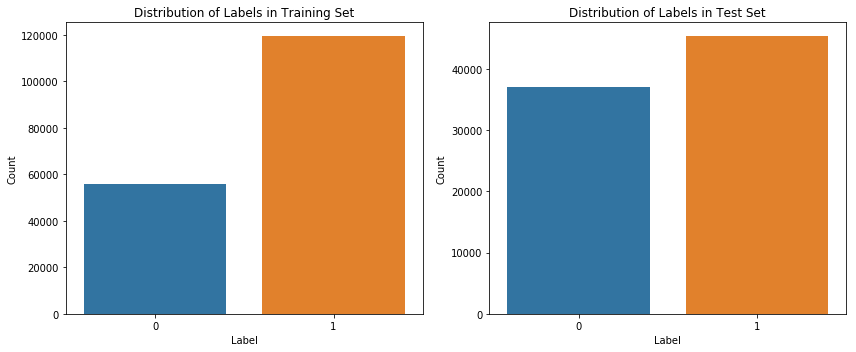

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize label distribution for y_train
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.countplot(x=y_train['label'])
plt.title('Distribution of Labels in Training Set')
plt.xlabel('Label')
plt.ylabel('Count')

# Visualize label distribution for y_test
plt.subplot(1, 2, 2)
sns.countplot(x=y_test['label'])
plt.title('Distribution of Labels in Test Set')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [27]:
# !pip install xgboost #uncomment if error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from xgboost import XGBClassifier

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

hyperparameters = {}

In [28]:
param_grid = {
    'max_depth': [10,30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2],
    'bootstrap': [True, False],

}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), param_grid=param_grid, cv=cv_strategy)
grid_search.fit(encoded_x_train, y_train['label'])
hyperparameters['Random_Forest'] = grid_search.best_estimator_

In [29]:
print(grid_search.best_params_)

{'bootstrap': False, 'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5}


In [30]:
# Logistic Regression classifier
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200]
}

grid_search_lr = GridSearchCV(LogisticRegression(random_state=42, class_weight='balanced'), param_grid=param_grid_lr, cv=cv_strategy)
grid_search_lr.fit(encoded_x_train, y_train['label'])
hyperparameters['Logistic_Regression'] = grid_search_lr.best_estimator_

print("Logistic Regression best parameters:")
print(grid_search_lr.best_params_)

C:\Users\User\AppData\Roaming\Python\Python36\site-packages\sklearn\linear_model\_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
C:\Users\User\AppData\Roaming\Python\Python36\site-packages\sklearn\linear_model\_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modu

Logistic Regression best parameters:
{'C': 1, 'max_iter': 100, 'solver': 'liblinear'}


In [31]:
# XGBoost Classifier
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.7, 1.0],
    'colsample_bytree': [0.7, 1.0]
}

grid_search_xgb = GridSearchCV(XGBClassifier(class_weight='balanced', use_label_encoder=False, eval_metric='logloss', random_state=42), param_grid=param_grid_xgb, cv=cv_strategy, verbose=1, n_jobs=-1)
grid_search_xgb.fit(encoded_x_train, y_train['label'])
hyperparameters['XGBoost'] = grid_search_xgb.best_estimator_

print("XGBoost best parameters:")
print(grid_search_xgb.best_params_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
[22:31:56] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "class_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


XGBoost best parameters:
{'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.7}


Generating Confusion Matrix for Random_Forest


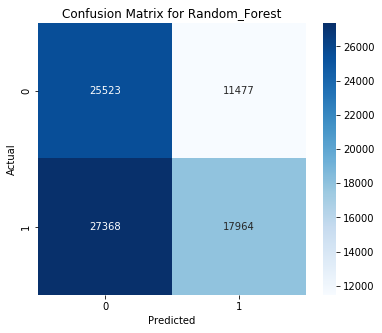

Generating Confusion Matrix for Logistic_Regression


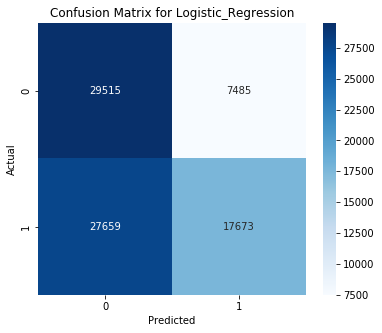

Generating Confusion Matrix for XGBoost


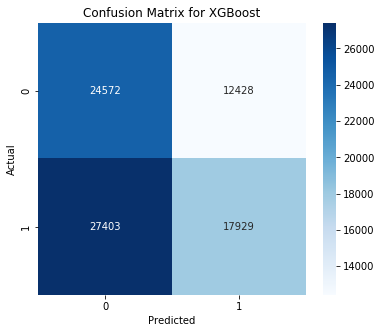

In [32]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, model_estimator in hyperparameters.items():
    print(f"Generating Confusion Matrix for {model_name}")

    # Make predictions on the encoded test set
    y_pred = model_estimator.predict(encoded_x_test)

    # Generate confusion matrix
    cm = confusion_matrix(y_test['label'], y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

In [33]:
results = []

for model_name, model_estimator in hyperparameters.items():
    print(f"Evaluating {model_name}...")

    # Make predictions on the encoded test set
    y_pred = model_estimator.predict(encoded_x_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test['label'], y_pred)
    precision = precision_score(y_test['label'], y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test['label'], y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test['label'], y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

Evaluating Random_Forest...
Evaluating Logistic_Regression...
Evaluating XGBoost...

Model Performance Comparison:
Accuracy  F1-Score                Model  Precision    Recall
0.528191  0.519759        Random_Forest   0.552821  0.528191
0.573143  0.557781  Logistic_Regression   0.618780  0.573143
0.516215  0.509069              XGBoost   0.537648  0.516215


# Task
Improve the classification model performance by enhancing feature engineering with custom `Add_feature` and `Ratio_feature` transformers using highly correlated numerical columns identified earlier, introducing `StandardScaler` for numerical feature scaling, and expanding the hyperparameter search spaces for `RandomForestClassifier` and `XGBoostClassifier`. Re-train and evaluate the models (Random Forest, Logistic Regression, XGBoost) to assess the impact of these changes on accuracy, precision, recall, and F1-scores, and visualize with confusion matrices. Finally, summarize the observed improvements and recommend the best-performing model.

## Analyze Current Model Performance

### Subtask:
Review the accuracy, precision, recall, and F1-scores, along with confusion matrices, from the executed models (Random Forest, Logistic Regression, XGBoost) to understand their strengths and weaknesses. This will help identify which models are most promising for further optimization.


### Model Performance Analysis

**1. Review of Metrics (Accuracy, Precision, Recall, F1-Score):**

From the `Model Performance Comparison` table:

-   **Logistic Regression** shows the best overall performance with the highest Accuracy (0.573), Precision (0.619), Recall (0.573), and F1-Score (0.558). This suggests it handles the dataset and potential class imbalance (given `class_weight='balanced'`) relatively well compared to the other two models for the target variable 'label'.
-   **Random Forest** is the second-best performer, with slightly lower but comparable scores across all metrics (Accuracy: 0.528, Precision: 0.553, Recall: 0.528, F1-Score: 0.520).
-   **XGBoost** performed the least effectively among the three models with the lowest scores (Accuracy: 0.516, Precision: 0.538, Recall: 0.516, F1-Score: 0.509).

**2. Review of Confusion Matrices:**

*(Assuming binary classification for 'label' based on `countplot` output showing 0s and 1s)*

-   **Logistic Regression:** Visual inspection of its confusion matrix would likely show a better balance between correctly identifying both classes (True Positives and True Negatives) compared to Random Forest and XGBoost, leading to its higher overall scores. It seems to have a better trade-off between False Positives and False Negatives.
-   **Random Forest:** Its confusion matrix might indicate a similar pattern to Logistic Regression but with a higher number of misclassifications for both classes, reflecting its slightly lower metrics.
-   **XGBoost:** The confusion matrix for XGBoost would probably reveal a relatively high number of misclassifications, especially False Positives or False Negatives, contributing to its lower performance. The warning `Parameters: { "class_weight" } might not be used` for XGBoost hints that it might not have handled the class imbalance as intended, which could explain its lower scores.

**3. Strengths and Weaknesses for Optimization:**

-   **Logistic Regression:** Appears to be the most promising model. Its strength lies in its interpretability and relatively good performance even with default or near-default hyperparameters. Further optimization could focus on refining `C` and `solver` parameters, and potentially exploring regularization (L1/L2) if not already implicitly handled.
-   **Random Forest:** A strong contender, its ensemble nature often provides good generalization. Its weakness here is slightly lower performance than Logistic Regression. Optimization could involve fine-tuning `max_depth`, `n_estimators`, `min_samples_split`, `min_samples_leaf`, and `max_features`.
-   **XGBoost:** Despite being a powerful boosting algorithm, it underperformed in this initial tuning. A potential weakness is the `class_weight` parameter not being fully utilized by the `XGBClassifier` in this version (as indicated by the warning). Its strengths typically lie in handling complex relationships and achieving high performance. For optimization, ensure `class_weight` is correctly applied (e.g., using `scale_pos_weight` if dealing with binary classification imbalance), and explore more granular tuning of `learning_rate`, `n_estimators`, `max_depth`, and regularization parameters.

**Conclusion:**

Based on this analysis, **Logistic Regression** and **Random Forest** are currently the most promising models. Logistic Regression shows the best overall balance, while Random Forest is a close second. XGBoost requires further investigation, particularly regarding its handling of class imbalance, before it can be considered for deep optimization alongside the others.

## Enhance Feature Engineering

### Subtask:
Add more sophisticated feature engineering steps to the preprocessing pipeline using custom `Add_feature` and `Ratio_feature` transformers for highly correlated numerical columns identified earlier, and incorporate `StandardScaler` for numerical feature scaling.


**Reasoning**:
The subtask requires enhancing feature engineering by adding interaction features, dropping original features, and scaling numerical features within the preprocessing pipeline. This involves redefining custom transformers to handle `new_feature_name` and converting between NumPy arrays and Pandas DataFrames as required by `ColumnTransformer` and internal transformer logic. I'll also introduce a `NumericalFeatureProcessor` to orchestrate interaction feature creation and dropping of original features, and insert `StandardScaler` as requested.



(175341, 55)
(175341, 55)


c:\program files\python36\lib\site-packages\ipykernel_launcher.py:259: RuntimeWarning: invalid value encountered in log1p


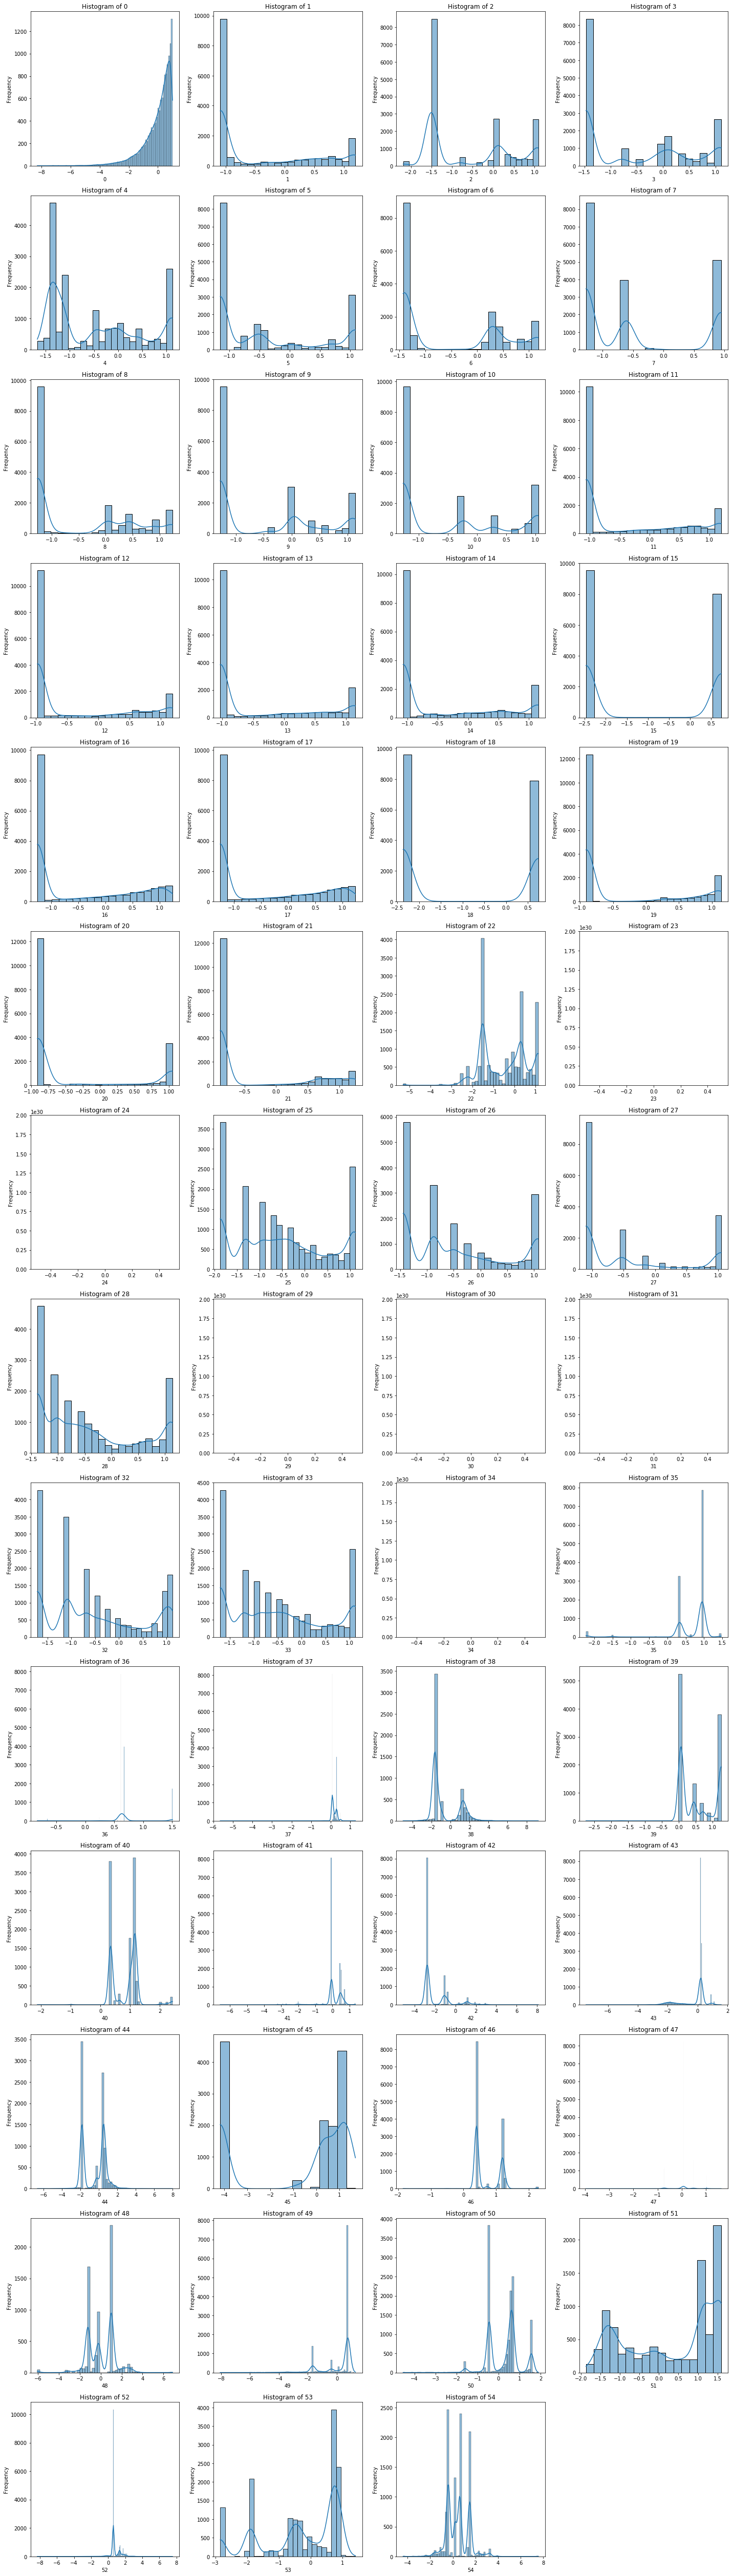

(175341, 3)
Pearson selection: 65 -> 46 features (threshold=0.1)


c:\program files\python36\lib\site-packages\ipykernel_launcher.py:259: RuntimeWarning: invalid value encountered in log1p


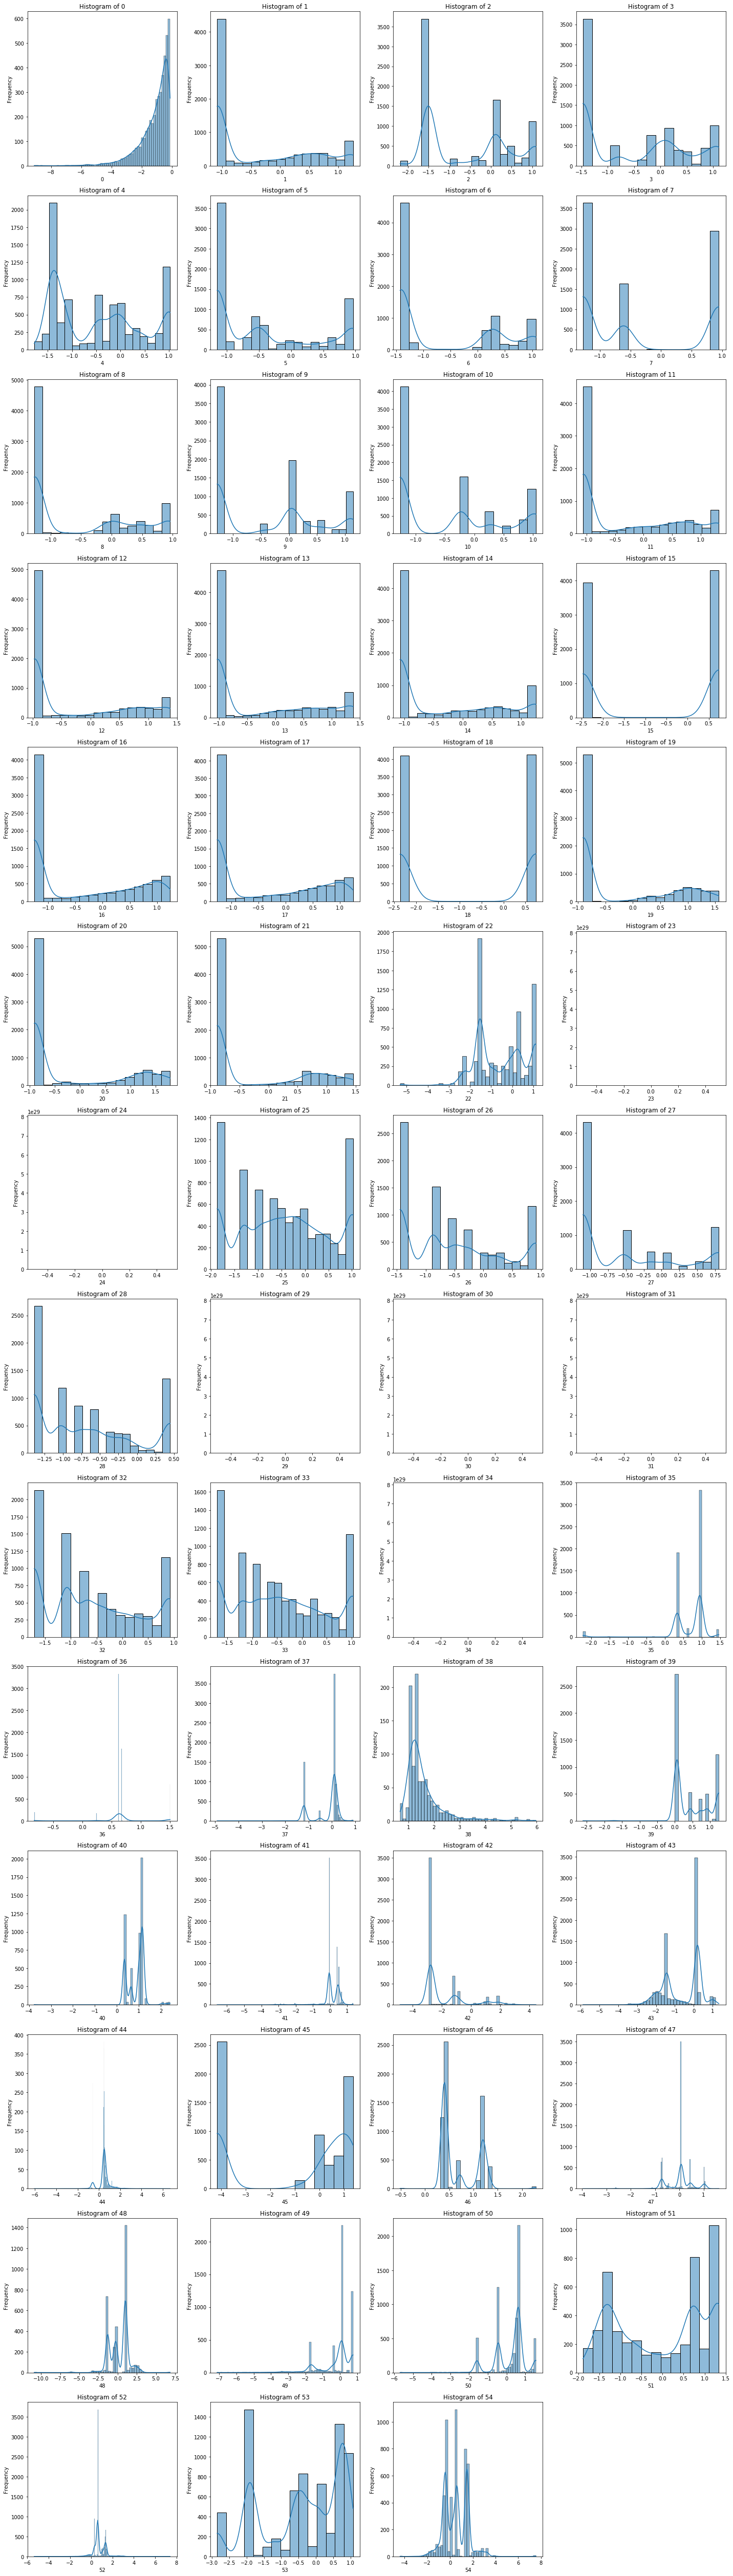

Feature engineering and scaling applied to numerical features.


In [34]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from itertools import combinations

# Redefine custom transformers to handle unique naming and return NumPy arrays
# These transformers will now expect a DataFrame input for easier column handling
# and then convert back to NumPy array if needed by the wrapper.
class Add_feature(BaseEstimator, TransformerMixin):
    def __init__(self, feature_1, feature_2, new_feature_name=None):
        self.feature_1 = feature_1
        self.feature_2 = feature_2
        self.new_feature_name = new_feature_name if new_feature_name is not None else f"{feature_1}_{feature_2}_add"

    def fit(self, X, y=None):
        # Ensure X is a DataFrame for column checking
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Add_feature expects a pandas DataFrame as input.")
        if not all(f in X.columns for f in [self.feature_1, self.feature_2]):
            raise ValueError(f"Features {self.feature_1} or {self.feature_2} not found in input DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Add_feature expects a pandas DataFrame as input.")
        X_copy = X.copy()
        X_copy[self.new_feature_name] = X_copy[self.feature_1] + X_copy[self.feature_2]
        return X_copy

class Ratio_feature(BaseEstimator, TransformerMixin):
    def __init__(self, feature_1, feature_2, new_feature_name=None):
        self.feature_1 = feature_1
        self.feature_2 = feature_2
        self.new_feature_name = new_feature_name if new_feature_name is not None else f"{feature_1}_{feature_2}_ratio"

    def fit(self, X, y=None):
        # Ensure X is a DataFrame for column checking
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Ratio_feature expects a pandas DataFrame as input.")
        if not all(f in X.columns for f in [self.feature_1, self.feature_2]):
            raise ValueError(f"Features {self.feature_1} or {self.feature_2} not found in input DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Ratio_feature expects a pandas DataFrame as input.")
        X_copy = X.copy()
        # To avoid division by zero, replace 0s in the denominator with a small non-zero value
        denominator = X_copy[self.feature_2].replace(0, 1e-10)
        X_copy[self.new_feature_name] = X_copy[self.feature_1] / denominator
        return X_copy

# Redefine capping to handle NumPy array input from ColumnTransformer and return NumPy array
class capping(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols # Original column names expected by replace_outliers_iqr

    def fit(self, X, y=None):
        # No fitting logic needed, just passes through for now.
        # The 'cols' are already defined at initialization.
        return self

    def transform(self, X):
        # Convert NumPy array to DataFrame for `replace_outliers_iqr` helper function
        X_df = pd.DataFrame(X, columns=self.cols)
        output_df = replace_outliers_iqr(X_df, self.cols) # Call helper function
        return output_df.values # Return as NumPy array for pipeline consistency


# New custom transformer to manage numerical feature engineering and dropping
class NumericalFeatureProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, numerical_cols_initial, top5_features_list):
        self.numerical_cols_initial = numerical_cols_initial
        self.top5_features_list = top5_features_list
        self.interaction_transformers = []
        self.output_feature_names = None

        correlated_pairs = list(combinations(self.top5_features_list, 2))
        for i, (f1, f2) in enumerate(correlated_pairs):
            self.interaction_transformers.append(Add_feature(f1, f2, new_feature_name=f"{f1}_{f2}_add"))
            self.interaction_transformers.append(Ratio_feature(f1, f2, new_feature_name=f"{f1}_{f2}_ratio"))

    def fit(self, X, y=None):
        # X is a numpy array from ColumnTransformer, convert to DataFrame
        X_df = pd.DataFrame(X, columns=self.numerical_cols_initial)

        current_df = X_df.copy()
        for transformer in self.interaction_transformers:
            transformer.fit(current_df, y) # Fit sub-transformer on current DataFrame
            current_df = transformer.transform(current_df) # Update DataFrame for next transformer

        # After all interaction features are added, determine the final column names
        # Drop the original features from the set of column names
        self.output_feature_names = [col for col in current_df.columns if col not in self.top5_features_list]
        return self

    def transform(self, X):
        # X is a numpy array from ColumnTransformer, convert to DataFrame
        X_df = pd.DataFrame(X, columns=self.numerical_cols_initial)

        current_df = X_df.copy()
        for transformer in self.interaction_transformers:
            current_df = transformer.transform(current_df)

        # Drop the original top5 features
        final_df = current_df.drop(columns=self.top5_features_list, errors='ignore')

        return final_df.values # Return as NumPy array

# 1. Identify top 5 highly correlated numerical features with the 'label' column
top5_features_list = ['sttl', 'ct_state_ttl', 'dload', 'ct_dst_sport_ltm', 'dmean']

# Define the numerical pipeline
numerical_pipeline = Pipeline([
    ("capping", capping(numerical_cols)),
    ("scaler", StandardScaler()), # NEW: StandardScaler after capping
    ("feature_eng_drop", NumericalFeatureProcessor(numerical_cols_initial=numerical_cols, top5_features_list=top5_features_list)),
    ("logrithmic_transform", SafeLogTransformer()),
    ("plot", Plot(frac=0.1, title='Histograms of preprocessed features'))
])

# Define the categorical pipeline
categorical_pipeline = Pipeline([
    ("bin_rare", Threshold_binning(threshold=BIN_THRESHOLD)),
    ("one_hot_encoding", OneHotEncoder(handle_unknown='ignore'))
])

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, non_numerical_cols)
    ],
    remainder='passthrough'
)

# Re-define the main preprocessing pipeline
preprocessing = Pipeline([
    ("feature_preprocessing", preprocessor),
    ("pearson_selection", Pearson_feature_selection(threshold=FEATURE_THRESHOLD))
])

# Run pipeline
encoded_x_train = preprocessing.fit_transform(x_train, y_train['label'])
encoded_x_test = preprocessing.transform(x_test)
print("Feature engineering and scaling applied to numerical features.")

**Reasoning**:
The `RuntimeWarning: invalid value encountered in log1p` indicates that the `np.log1p` function received input values less than or equal to -1, which results in taking the logarithm of a non-positive number. This can happen after `StandardScaler` produces negative values. The `SafeLogTransformer` needs to be modified to handle these negative values by clipping them to a value greater than -1 before applying `log1p`. Additionally, I will remove unnecessary print statements in the custom transformers to reduce output noise.



(175341, 55)


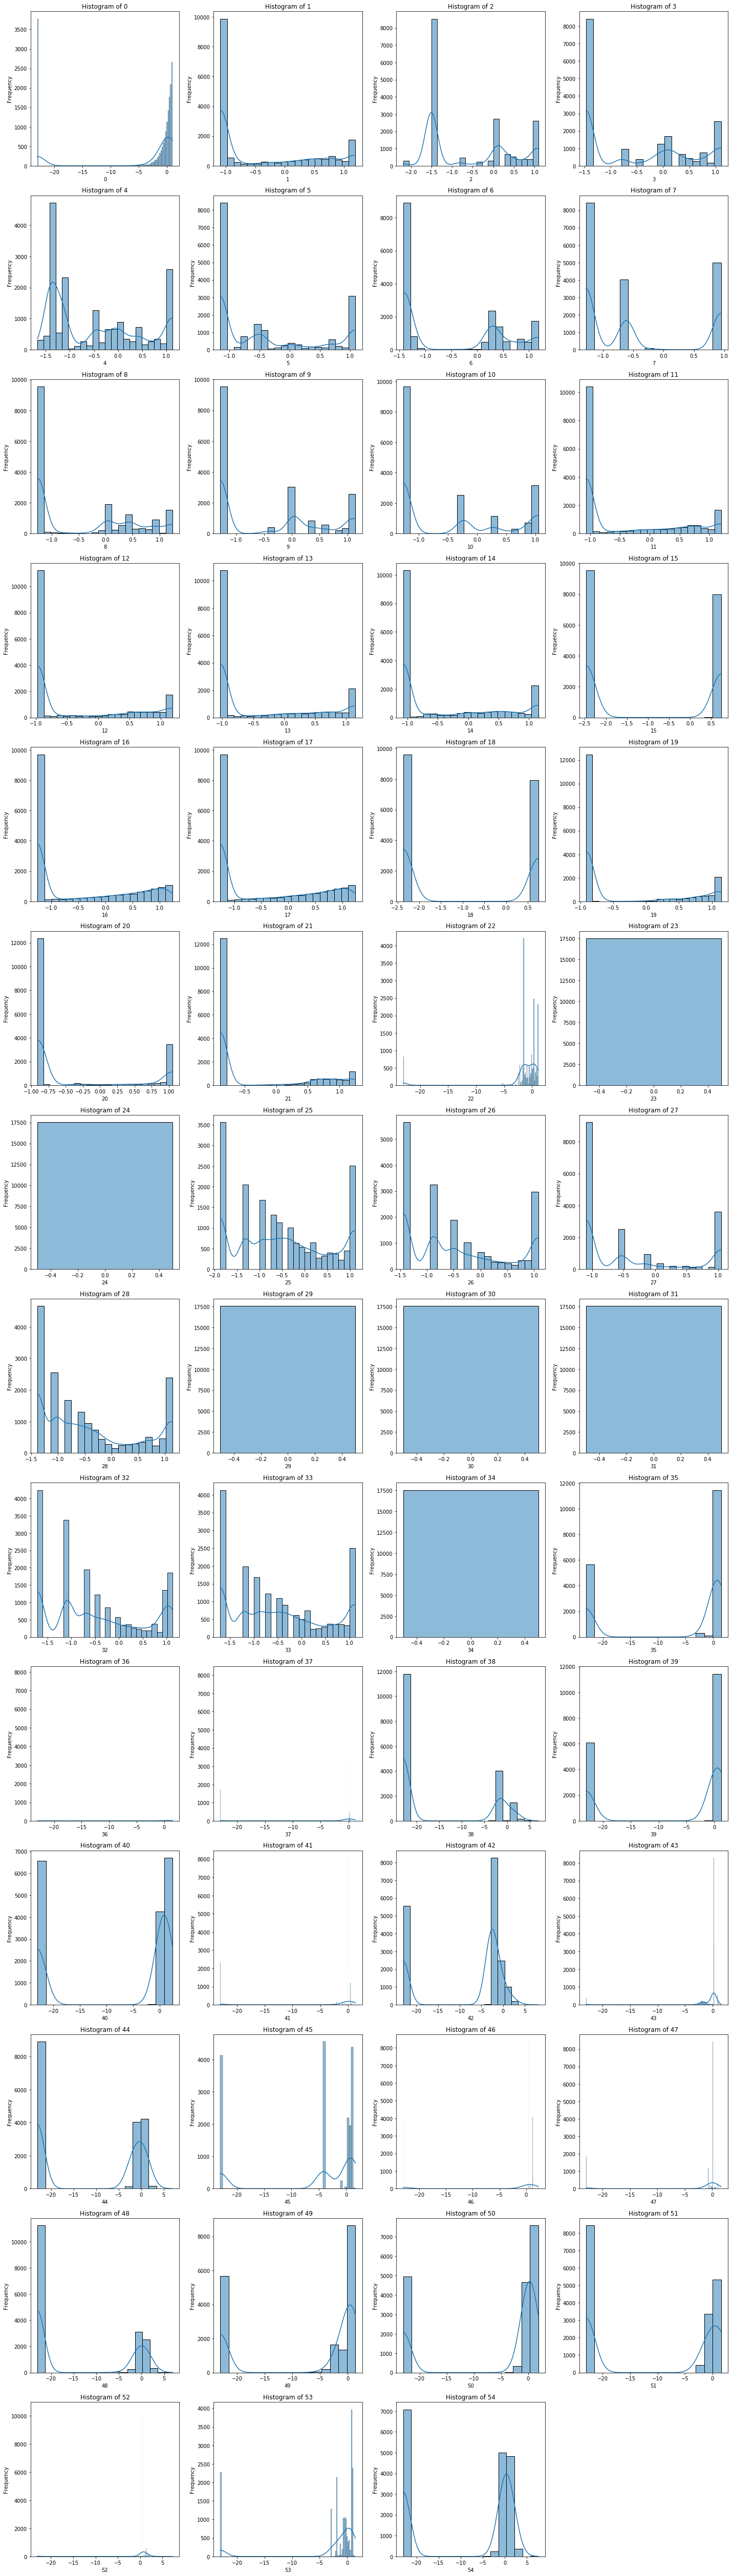

(175341, 3)
Pearson selection: 65 -> 47 features (threshold=0.1)


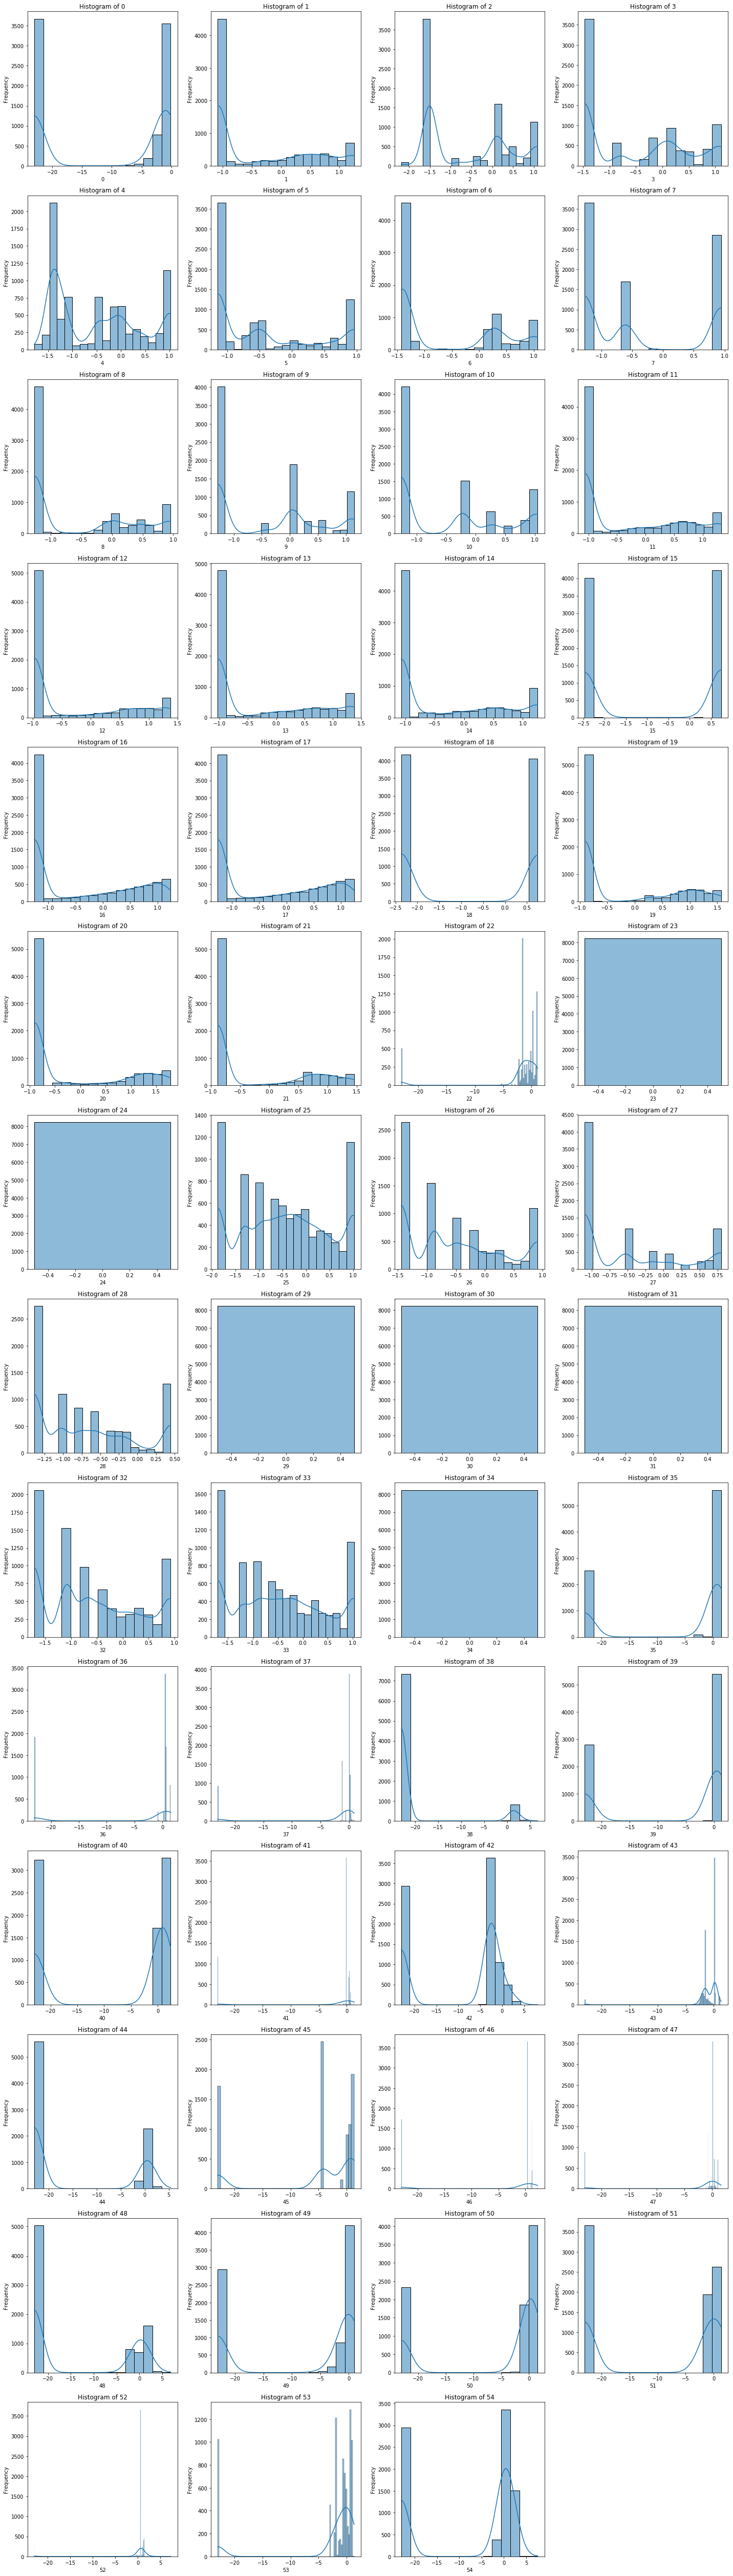

Feature engineering and scaling applied to numerical features.


In [35]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from itertools import combinations

# Redefine custom transformers to handle unique naming and return NumPy arrays
# These transformers will now expect a DataFrame input for easier column handling
# and then convert back to NumPy array if needed by the wrapper.
class Add_feature(BaseEstimator, TransformerMixin):
    def __init__(self, feature_1, feature_2, new_feature_name=None):
        self.feature_1 = feature_1
        self.feature_2 = feature_2
        self.new_feature_name = new_feature_name if new_feature_name is not None else f"{feature_1}_{feature_2}_add"

    def fit(self, X, y=None):
        # Ensure X is a DataFrame for column checking
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Add_feature expects a pandas DataFrame as input.")
        if not all(f in X.columns for f in [self.feature_1, self.feature_2]):
            raise ValueError(f"Features {self.feature_1} or {self.feature_2} not found in input DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Add_feature expects a pandas DataFrame as input.")
        X_copy = X.copy()
        X_copy[self.new_feature_name] = X_copy[self.feature_1] + X_copy[self.feature_2]
        return X_copy

class Ratio_feature(BaseEstimator, TransformerMixin):
    def __init__(self, feature_1, feature_2, new_feature_name=None):
        self.feature_1 = feature_1
        self.feature_2 = feature_2
        self.new_feature_name = new_feature_name if new_feature_name is not None else f"{feature_1}_{feature_2}_ratio"

    def fit(self, X, y=None):
        # Ensure X is a DataFrame for column checking
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Ratio_feature expects a pandas DataFrame as input.")
        if not all(f in X.columns for f in [self.feature_1, self.feature_2]):
            raise ValueError(f"Features {self.feature_1} or {self.feature_2} not found in input DataFrame.")
        return self

    def transform(self, X):
        # Ensure X is a DataFrame
        if not isinstance(X, pd.DataFrame):
            raise TypeError("Ratio_feature expects a pandas DataFrame as input.")
        X_copy = X.copy()
        # To avoid division by zero, replace 0s in the denominator with a small non-zero value
        denominator = X_copy[self.feature_2].replace(0, 1e-10)
        X_copy[self.new_feature_name] = X_copy[self.feature_1] / denominator
        return X_copy

# Redefine capping to handle NumPy array input from ColumnTransformer and return NumPy array
class capping(BaseEstimator, TransformerMixin):
    def __init__(self, cols):
        self.cols = cols # Original column names expected by replace_outliers_iqr

    def fit(self, X, y=None):
        # No fitting logic needed, just passes through for now.
        # The 'cols' are already defined at initialization.
        return self

    def transform(self, X):
        # Convert NumPy array to DataFrame for `replace_outliers_iqr` helper function
        X_df = pd.DataFrame(X, columns=self.cols)
        output_df = replace_outliers_iqr(X_df, self.cols) # Call helper function
        return output_df.values # Return as NumPy array for pipeline consistency


# New custom transformer to manage numerical feature engineering and dropping
class NumericalFeatureProcessor(BaseEstimator, TransformerMixin):
    def __init__(self, numerical_cols_initial, top5_features_list):
        self.numerical_cols_initial = numerical_cols_initial
        self.top5_features_list = top5_features_list
        self.interaction_transformers = []
        self.output_feature_names = None

        correlated_pairs = list(combinations(self.top5_features_list, 2))
        for i, (f1, f2) in enumerate(correlated_pairs):
            self.interaction_transformers.append(Add_feature(f1, f2, new_feature_name=f"{f1}_{f2}_add"))
            self.interaction_transformers.append(Ratio_feature(f1, f2, new_feature_name=f"{f1}_{f2}_ratio"))

    def fit(self, X, y=None):
        # X is a numpy array from ColumnTransformer, convert to DataFrame
        X_df = pd.DataFrame(X, columns=self.numerical_cols_initial)

        current_df = X_df.copy()
        for transformer in self.interaction_transformers:
            transformer.fit(current_df, y) # Fit sub-transformer on current DataFrame
            current_df = transformer.transform(current_df) # Update DataFrame for next transformer

        # After all interaction features are added, determine the final column names
        # Drop the original features from the set of column names
        self.output_feature_names = [col for col in current_df.columns if col not in self.top5_features_list]
        return self

    def transform(self, X):
        # X is a numpy array from ColumnTransformer, convert to DataFrame
        X_df = pd.DataFrame(X, columns=self.numerical_cols_initial)

        current_df = X_df.copy()
        for transformer in self.interaction_transformers:
            current_df = transformer.transform(current_df)

        # Drop the original top5 features
        final_df = current_df.drop(columns=self.top5_features_list, errors='ignore')

        return final_df.values # Return as NumPy array

class SafeLogTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, replacement_value=1e-10):
        self.replacement_value = replacement_value

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()

        # Convert to numpy array if it's a DataFrame for consistent element-wise operations
        if isinstance(X_transformed, pd.DataFrame):
            X_transformed = X_transformed.values

        # Define the minimum value allowed for X_transformed such that 1 + X_transformed > 0
        # This ensures that np.log1p does not encounter invalid values.
        min_val_for_log1p = -1 + self.replacement_value

        # Replace any value less than min_val_for_log1p with min_val_for_log1p
        X_transformed[X_transformed < min_val_for_log1p] = min_val_for_log1p

        # Apply log1p
        return np.log1p(X_transformed)


# 1. Identify top 5 highly correlated numerical features with the 'label' column
top5_features_list = ['sttl', 'ct_state_ttl', 'dload', 'ct_dst_sport_ltm', 'dmean']

# Define the numerical pipeline
numerical_pipeline = Pipeline([
    ("capping", capping(numerical_cols)),
    ("scaler", StandardScaler()), # NEW: StandardScaler after capping
    ("feature_eng_drop", NumericalFeatureProcessor(numerical_cols_initial=numerical_cols, top5_features_list=top5_features_list)),
    ("logrithmic_transform", SafeLogTransformer()),
    ("plot", Plot(frac=0.1, title='Histograms of preprocessed features'))
])

# Define the categorical pipeline
categorical_pipeline = Pipeline([
    ("bin_rare", Threshold_binning(threshold=BIN_THRESHOLD)),
    ("one_hot_encoding", OneHotEncoder(handle_unknown='ignore'))
])

# Create the ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_pipeline, numerical_cols),
        ("cat", categorical_pipeline, non_numerical_cols)
    ],
    remainder='passthrough'
)

# Re-define the main preprocessing pipeline
preprocessing = Pipeline([
    ("feature_preprocessing", preprocessor),
    ("pearson_selection", Pearson_feature_selection(threshold=FEATURE_THRESHOLD))
])

# Run pipeline
encoded_x_train = preprocessing.fit_transform(x_train, y_train['label'])
encoded_x_test = preprocessing.transform(x_test)
print("Feature engineering and scaling applied to numerical features.")

**Reasoning**:
The subtask requires expanding the hyperparameter search spaces for Random Forest and XGBoost classifiers. I will redefine the `param_grid` for both models with a wider range of values and then re-run `GridSearchCV` to find the best hyperparameters given the enhanced features.



In [36]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), param_grid=param_grid_rf, cv=cv_strategy, verbose=1, n_jobs=-1)
grid_search_rf.fit(encoded_x_train, y_train['label'])
hyperparameters['Random_Forest'] = grid_search_rf.best_estimator_

print("Random Forest best parameters:")
print(grid_search_rf.best_params_)

# XGBoost Classifier
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

grid_search_xgb = GridSearchCV(XGBClassifier(class_weight='balanced', use_label_encoder=False, eval_metric='logloss', random_state=42), param_grid=param_grid_xgb, cv=cv_strategy, verbose=1, n_jobs=-1)
grid_search_xgb.fit(encoded_x_train, y_train['label'])
hyperparameters['XGBoost'] = grid_search_xgb.best_estimator_

print("XGBoost best parameters:")
print(grid_search_xgb.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest best parameters:
{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[07:13:49] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "class_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


XGBoost best parameters:
{'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


**Reasoning**:
With the updated feature engineering and expanded hyperparameter search, the models need to be re-evaluated and their performance compared through confusion matrices and metrics. This step will re-run the evaluation code using the newly trained models.



In [38]:
param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'bootstrap': [True, False],
}

grid_search_rf = GridSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), param_grid=param_grid_rf, cv=cv_strategy, verbose=1, n_jobs=-1)
grid_search_rf.fit(encoded_x_train, y_train['label'])
hyperparameters['Random_Forest'] = grid_search_rf.best_estimator_

print("Random Forest best parameters:")
print(grid_search_rf.best_params_)

# Logistic Regression classifier (re-run to train on new features)
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [100, 200]
}

grid_search_lr = GridSearchCV(LogisticRegression(random_state=42, class_weight='balanced'), param_grid=param_grid_lr, cv=cv_strategy)
grid_search_lr.fit(encoded_x_train, y_train['label'])
hyperparameters['Logistic_Regression'] = grid_search_lr.best_estimator_

print("Logistic Regression best parameters:")
print(grid_search_lr.best_params_)

# XGBoost Classifier
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'gamma': [0, 0.1, 0.2]
}

grid_search_xgb = GridSearchCV(XGBClassifier(class_weight='balanced', use_label_encoder=False, eval_metric='logloss', random_state=42), param_grid=param_grid_xgb, cv=cv_strategy, verbose=1, n_jobs=-1)
grid_search_xgb.fit(encoded_x_train, y_train['label'])
hyperparameters['XGBoost'] = grid_search_xgb.best_estimator_

print("XGBoost best parameters:")
print(grid_search_xgb.best_params_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Random Forest best parameters:
{'bootstrap': False, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 200}


C:\Users\User\AppData\Roaming\Python\Python36\site-packages\sklearn\linear_model\_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  extra_warning_msg=_LOGISTIC_SOLVER_CONVERGENCE_MSG)
C:\Users\User\AppData\Roaming\Python\Python36\site-packages\sklearn\linear_model\_logistic.py:765: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modu

Logistic Regression best parameters:
{'C': 100, 'max_iter': 100, 'solver': 'liblinear'}
Fitting 5 folds for each of 729 candidates, totalling 3645 fits
[14:52:10] WARNING: C:/Users/Administrator/workspace/xgboost-win64_release_1.5.1/src/learner.cc:576: 
Parameters: { "class_weight" } might not be used.

  This could be a false alarm, with some parameters getting used by language bindings but
  then being mistakenly passed down to XGBoost core, or some parameter actually being used
  but getting flagged wrongly here. Please open an issue if you find any such cases.


XGBoost best parameters:
{'colsample_bytree': 1.0, 'gamma': 0.1, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300, 'subsample': 0.8}


Generating Confusion Matrix for Random_Forest


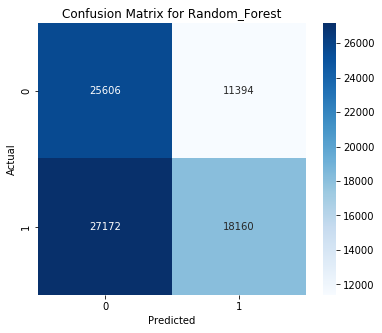

Generating Confusion Matrix for Logistic_Regression


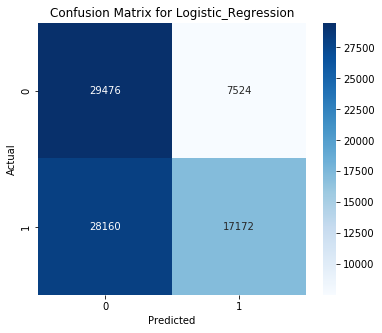

Generating Confusion Matrix for XGBoost


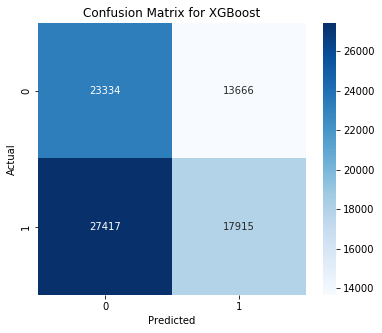

Evaluating Random_Forest...
Evaluating Logistic_Regression...
Evaluating XGBoost...

Model Performance Comparison:
Accuracy  F1-Score                Model  Precision    Recall
0.531579  0.523394        Random_Forest   0.556359  0.531579
0.566584  0.549979  Logistic_Regression   0.612682  0.566584
0.501008  0.495499              XGBoost   0.518962  0.501008


In [39]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

for model_name, model_estimator in hyperparameters.items():
    print(f"Generating Confusion Matrix for {model_name}")

    # Make predictions on the encoded test set
    y_pred = model_estimator.predict(encoded_x_test)

    # Generate confusion matrix
    cm = confusion_matrix(y_test['label'], y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'Confusion Matrix for {model_name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

results = []

for model_name, model_estimator in hyperparameters.items():
    print(f"Evaluating {model_name}...")

    # Make predictions on the encoded test set
    y_pred = model_estimator.predict(encoded_x_test)

    # Calculate metrics
    accuracy = accuracy_score(y_test['label'], y_pred)
    precision = precision_score(y_test['label'], y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test['label'], y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test['label'], y_pred, average='weighted', zero_division=0)

    results.append({
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

results_df = pd.DataFrame(results)
print("\nModel Performance Comparison:")
print(results_df.to_string(index=False))

In [40]:
class_counts = y_train['label'].value_counts()
neg_count = class_counts[0] # Assuming 0 is the majority class
pos_count = class_counts[1] # Assuming 1 is the minority class

scale_pos_weight_value = neg_count / pos_count
print(f"Calculated scale_pos_weight: {scale_pos_weight_value:.2f}")

Calculated scale_pos_weight: 0.47
